# L3 9.2 VC and PE Exit Prediction

This notebook builds a leakage-controlled private-market exit prediction workflow on the live Crunchbase and Preqin data. The empirical unit is a company-quarter observation, so each company can enter the risk set multiple times as new financing, patent, web, and institutional-coverage information becomes visible.

The main prediction task is whether a company reaches hard timely liquidity within the next eight quarters. Hard liquidity includes IPO, M&A/acquisition, and sponsor sale events. The notebook uses dated event tables and point-in-time feature construction so that each row only uses information available at or before the observation quarter.

The workflow covers feature availability, residual Rank-IC screening, model estimation, calibration, route support, policy-style ranking diagnostics, and family-level promotion gates. The baseline binary hazard plus conditional route model is implemented directly in this notebook, alongside Logistic Regression, SVM with RBF kernel, and XGBoost-style boosting on the same risk set.

## Study Design

All model variants use the same company-quarter rows and the same target:

`realized_hard_timely_liquidity_by_horizon = 1` when a hard liquidity event occurs after the observation quarter, from `t + 1` through `t + 8`.

The feature space is organized into two layers:

- baseline features from a transparent stage-1 hazard specification.
- candidate feature families from the expanded feature backlog, attached to the same company-quarter panel when the source fields are present.

Missing or unsupported feature families are kept in the availability table instead of being silently dropped. This makes the notebook usable both as a modeling run and as an audit trail for which features can actually be constructed from the current data package.

## Label and Feature Construction

### Label

The model uses a company-quarter risk set with dated label timing. Each row is a company observed at quarter `t`, and the main label is:

```text
y = 1 if IPO, M&A/acquisition, or sponsor sale occurs from quarter t+1 through t+8
    0 otherwise
```

The label column used by the model harness is `realized_hard_timely_liquidity_by_horizon`, with `HORIZON_Q = 8`. Current-status fields such as `operating_status` are not used as labels or predictors.

### Baseline Feature Space

| Feature block | Construction |
|---|---|
| `age_q`, `log_age_years` | Company age at observation quarter `t`, in quarters and as `log1p(age_q / 4)`. |
| `time_since_last_round_q` | Quarters since the latest observed round visible strictly before `t`. |
| `log_last_round_usd`, `last_round_amount_missing` | `log1p` of the latest observed round amount visible strictly before `t`, plus an explicit missingness flag. |
| `log_num_investors_last_round`, `num_investors_missing` | `log1p` of the latest observed investor count, plus an explicit missingness flag. |
| `sponsor_score` | Preqin institutional confirmation plus investor-count support. |
| `sector_bucket` dummies | Coarse sector bucket dummies from company text/source mapping. |
| `stage_bucket` / `last_stage` dummies | Coarse stage bucket dummies from latest observed round stage/type. |
| `quarter_idx` | Time control used by the sklearn models after scaling. |

### Candidate Feature Families

| Family | Included or attempted variables |
|---|---|
| `syndicate_investor_supported` | `lead_prior_hard_exit_rate_asof`, `syndicate_investor_centrality_max`, `insider_only_round_flag`, `has_lead_investor_flag`, current and first-round investor-count features. |
| `founder_funding_dynamics_supported` | `round_velocity`, `inter_round_gap_vs_cohort_z`, `inter_round_gap_missing`, `log_cum_raised_asof`, first-round amount/timing features, `founder_count`, `founder_count_missing`, `log_founder_count`, founder record counts, founder identifier coverage, `founder_prior_founding_count`, `founder_prior_exit_flag`, `valuation_step_up_last`. |
| `patent_quality` | `backward_cites_mean_at_grant`, `grant_lag_mean`, `patent_grants_asof` from WRDS patents matched by normalized organization name. |
| `common_crawl` | `cc_presence_streak`, `cc_first_seen_web_age`, `cc_decay_transition_flag`, `cc_coverage_missing_flag` from homepage archive-proxy cutoff panels when available. The companion crawler writes annual 2010-2023 cutoff panels under `data/live_root/Crawl`; each cutoff becomes visible from the next quarter. |
| `preqin_institutional_confirmation` | `preqin_institutional_confirmation`, `preqin_deal_count_asof`, `quarters_since_first_preqin_deal`, `preqin_deal_size_sum_asof`, `crosswalk_matched_asof`, plus partner-provided match score, low/high confidence flags, accepted-match flag, and match-quality score. |
| `partner_profile_quality` | `has_website_url`, `has_short_description`, `crunchbase_category_count`, `log_crunchbase_category_count`, and `profile_completeness_score` from `data/live_root/Partner_exports/partner_feature_matrix.csv`; partner label fields are explicitly excluded. |
| `buyout_valuation_proxy` | `log_enterprise_value_at_entry`, `enterprise_value_missing_flag`; revenue/EBITDA fields are audited but unavailable in the current extract. |
| `noise_placebo` | Deterministic random noise used to test whether the promotion gate is too permissive. |

All event-based features must be dated before the observation quarter. Operationally, events in quarter `q` first become visible to a model row in quarter `q + 1`, so the model never uses same-quarter financing, patent, Preqin, or exit information to score quarter `t`.

In [21]:
from __future__ import annotations

import json
import math
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    from sklearn.ensemble import HistGradientBoostingClassifier
    HAS_XGBOOST = False

PROJECT_ROOT = Path(r"D:\Columbia\SummerProject\L3_9_2_VC_and_PE_Exit_Prediction_distribution")
LIVE_ROOT = PROJECT_ROOT / "data" / "live_root"
OUTPUT_DIR = PROJECT_ROOT / "project" / "outputs" / "reference_benchmark"
CACHE_DIR = OUTPUT_DIR / "cache"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
HORIZON_Q = 8
ANALYSIS_START = "2010Q1"
TRAIN_END = "2018Q4"
VALIDATION_END = "2021Q4"
TEST_END = "2023Q4"
np.random.seed(RANDOM_SEED)

print("Project root:", PROJECT_ROOT)
print("Live root:", LIVE_ROOT)
print("Output dir:", OUTPUT_DIR)

Project root: D:\Columbia\SummerProject\L3_9_2_VC_and_PE_Exit_Prediction_distribution
Live root: D:\Columbia\SummerProject\L3_9_2_VC_and_PE_Exit_Prediction_distribution\data\live_root
Output dir: D:\Columbia\SummerProject\L3_9_2_VC_and_PE_Exit_Prediction_distribution\project\outputs\reference_benchmark


## Helper Functions

In [22]:
def normalize_timestamp(series: pd.Series) -> pd.Series:
    values = pd.to_datetime(series, errors="coerce", utc=True)
    return values.dt.tz_convert(None)

def quarter_idx_from_dates(values) -> pd.Series:
    dt = pd.to_datetime(values, errors="coerce")
    return (dt.dt.year * 4 + ((dt.dt.month - 1) // 3)).astype("Int64")

def quarter_idx_from_label(label: str) -> int:
    match = re.fullmatch(r"(\d{4})Q([1-4])", str(label).strip())
    if not match:
        raise ValueError(f"Bad quarter label: {label}")
    year, q = int(match.group(1)), int(match.group(2))
    return year * 4 + (q - 1)

def quarter_label_from_idx(idx: int) -> str:
    return f"{idx // 4}Q{idx % 4 + 1}"

def normalize_domain(value) -> str:
    if pd.isna(value):
        return ""
    s = str(value).strip().lower()
    s = re.sub(r"^https?://", "", s)
    s = re.sub(r"^www\.", "", s)
    s = s.split("/")[0].split("?")[0].strip()
    return s

def normalize_name(value) -> str:
    if pd.isna(value):
        return ""
    s = str(value).lower()
    s = re.sub(r"&", " and ", s)
    s = re.sub(r"[^a-z0-9]+", " ", s)
    s = re.sub(r"\b(inc|llc|ltd|limited|corp|corporation|co|company|plc|gmbh|sa|sas|ag)\b", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def read_csv_optional(path: Path, usecols: list[str] | None = None) -> pd.DataFrame:
    if not path.exists():
        print("Missing:", path)
        return pd.DataFrame(columns=usecols or [])
    header = pd.read_csv(path, nrows=0).columns.tolist()
    cols = [c for c in (usecols or header) if c in header]
    frame = pd.read_csv(path, usecols=cols, low_memory=False)
    for col in (usecols or []):
        if col not in frame.columns:
            frame[col] = np.nan
    return frame[usecols] if usecols else frame

def read_first_preqin_csv(directory: Path, desired_columns: list[str]) -> pd.DataFrame:
    csv_files = sorted(directory.glob("*.csv"))
    if not csv_files:
        print("Missing Preqin CSV under:", directory)
        return pd.DataFrame(columns=desired_columns)
    source_path = csv_files[0]
    header = pd.read_csv(source_path, nrows=0, low_memory=False).columns.tolist()
    usecols = [c for c in desired_columns if c in header]
    frame = pd.read_csv(source_path, usecols=usecols, low_memory=False)
    print("Read Preqin CSV:", source_path)
    for col in desired_columns:
        if col not in frame.columns:
            frame[col] = np.nan
    return frame[desired_columns]

def sector_bucket(text) -> str:
    s = str(text or "").lower()
    if any(x in s for x in ["software", "saas", "cloud", "data", "ai ", "artificial intelligence"]):
        return "software"
    if any(x in s for x in ["health", "medical", "biotech", "pharma", "therapeutic"]):
        return "healthcare"
    if any(x in s for x in ["financ", "bank", "payment", "insur", "lending", "credit"]):
        return "financial"
    if any(x in s for x in ["energy", "solar", "battery", "climate", "carbon"]):
        return "energy"
    return "other"

def stage_bucket(stage) -> str:
    s = str(stage or "").lower()
    if "seed" in s or "angel" in s or "pre_seed" in s:
        return "seed"
    if "series_a" in s or "series a" in s:
        return "series_a"
    if "series_b" in s or "series b" in s:
        return "series_b"
    if any(x in s for x in ["series_c", "series c", "late", "growth", "private_equity"]):
        return "growth"
    if "buyout" in s:
        return "buyout"
    return "unknown"

## Load Live Root Data

In [23]:
cb_root = LIVE_ROOT / "CrunchBase"
preqin_root = LIVE_ROOT / "WRDS" / "Preqin"

companies = read_csv_optional(cb_root / "companies.csv", [
    "company_uuid", "name", "description", "website", "founded_on", "operating_status",
    "last_funding_at", "num_funding_rounds", "hq_city", "hq_country", "collected_at"
])
rounds = read_csv_optional(cb_root / "funding_rounds.csv", [
    "company_uuid", "announced_on", "investment_type", "money_raised_usd", "num_investors"
])
acq = read_csv_optional(cb_root / "acquisitions.csv", [
    "acquiree_uuid", "announced_on", "price_usd", "acquisition_type"
])
ipos = read_csv_optional(cb_root / "ipos.csv", [
    "company_uuid", "went_public_on", "money_raised_usd", "stock_exchange"
])

vc_deals = read_first_preqin_csv(preqin_root / "Venture Capital Deals", [
    "portfolio_company_id", "deal_date", "ventureid", "stage", "deal_status",
    "investment_status", "deal_financing_size_usd", "total_known_funding_usd",
    "portfolio_company_name", "portfolio_company_website", "portfolio_company_country",
    "portfolio_company_region", "year_established"
])
buyout_deals = read_first_preqin_csv(preqin_root / "Buyout Deals", [
    "portfolio_company_id", "deal_date", "buyout_id", "fund_id", "firm_id",
    "investment_type", "deal_status", "investment_status", "deal_size_usd",
    "enterprisevalue", "portfolio_company_name", "portfolio_company_website",
    "portfolio_company_country", "portfolio_company_region", "primary_industry",
    "industry_classification", "year_established"
])
patents = read_csv_optional(LIVE_ROOT / "WRDS" / "WRDS - Patents" / "wrdsapps.patents.csv", [
    "patnum", "grantdate", "appldate", "ee_name", "backward_cites", "forward_cites"
])
partner_features = read_csv_optional(LIVE_ROOT / "Partner_exports" / "partner_feature_matrix.csv", [
    "company_uuid", "crunchbase_num_founders", "crunchbase_founder_identifier_count",
    "has_website_url", "has_short_description", "crunchbase_category_count",
    "founder_record_count", "preqin_match_score", "preqin_confidence_tier",
    "preqin_accepted_match_asof_review", "first_funding_date", "first_round_amount_usd",
    "first_round_investor_count",
])

for frame, date_cols in [
    (companies, ["founded_on", "last_funding_at", "collected_at"]),
    (rounds, ["announced_on"]),
    (acq, ["announced_on"]),
    (ipos, ["went_public_on"]),
    (vc_deals, ["deal_date"]),
    (buyout_deals, ["deal_date"]),
    (patents, ["grantdate", "appldate"]),
    (partner_features, ["first_funding_date"]),
]:
    for col in date_cols:
        if col in frame.columns:
            frame[col] = normalize_timestamp(frame[col])

rounds["money_raised_usd"] = pd.to_numeric(rounds.get("money_raised_usd"), errors="coerce")
rounds["num_investors"] = pd.to_numeric(rounds.get("num_investors"), errors="coerce")
patents["backward_cites"] = pd.to_numeric(patents.get("backward_cites"), errors="coerce")
patents["forward_cites"] = pd.to_numeric(patents.get("forward_cites"), errors="coerce")

display(pd.DataFrame({
    "table": ["companies", "rounds", "acquisitions", "ipos", "preqin_vc_deals", "preqin_buyout_deals", "wrds_patents", "partner_features"],
    "rows": [len(companies), len(rounds), len(acq), len(ipos), len(vc_deals), len(buyout_deals), len(patents), len(partner_features)],
}))

Read Preqin CSV: D:\Columbia\SummerProject\L3_9_2_VC_and_PE_Exit_Prediction_distribution\data\live_root\WRDS\Preqin\Venture Capital Deals\Venture Capital Deals.csv
Read Preqin CSV: D:\Columbia\SummerProject\L3_9_2_VC_and_PE_Exit_Prediction_distribution\data\live_root\WRDS\Preqin\Buyout Deals\Buyout Deals.csv


,table,rows
0,companies,574938
1,rounds,789273
2,acquisitions,202620
3,ipos,55296
4,preqin_vc_deals,370780
5,preqin_buyout_deals,130983
6,wrds_patents,145869
7,partner_features,4387014


## Build Preqin-Crunchbase Crosswalk

In [24]:
def build_preqin_company_rows(vc_deals: pd.DataFrame, buyout_deals: pd.DataFrame) -> pd.DataFrame:
    vc = vc_deals[[
        "portfolio_company_id", "portfolio_company_name", "portfolio_company_website",
        "portfolio_company_country", "deal_date", "deal_financing_size_usd"
    ]].copy()
    vc["preqin_deal_source"] = "vc"
    vc["preqin_deal_size_usd"] = pd.to_numeric(vc["deal_financing_size_usd"], errors="coerce")
    vc["enterprisevalue"] = np.nan
    bo = buyout_deals[[
        "portfolio_company_id", "portfolio_company_name", "portfolio_company_website",
        "portfolio_company_country", "deal_date", "deal_size_usd", "enterprisevalue"
    ]].copy()
    bo["preqin_deal_source"] = "buyout"
    bo["preqin_deal_size_usd"] = pd.to_numeric(bo["deal_size_usd"], errors="coerce")
    bo["enterprisevalue"] = pd.to_numeric(bo["enterprisevalue"], errors="coerce")
    out = pd.concat([vc, bo], ignore_index=True)
    out["norm_domain"] = out["portfolio_company_website"].map(normalize_domain)
    out["norm_name"] = out["portfolio_company_name"].map(normalize_name)
    out["country_key"] = out["portfolio_company_country"].astype(str).str.lower().str.strip()
    return out

preqin_companies = build_preqin_company_rows(vc_deals, buyout_deals)
cb_match = companies[["company_uuid", "name", "website", "hq_country"]].copy()
cb_match["norm_domain"] = cb_match["website"].map(normalize_domain)
cb_match["norm_name"] = cb_match["name"].map(normalize_name)
cb_match["country_key"] = cb_match["hq_country"].astype(str).str.lower().str.strip()

domain_matches = cb_match[cb_match["norm_domain"].ne("")].merge(
    preqin_companies[preqin_companies["norm_domain"].ne("")],
    on="norm_domain",
    how="inner",
    suffixes=("_cb", "_preqin"),
)
domain_matches["match_method"] = "domain"

name_country_matches = cb_match[cb_match["norm_name"].ne("")].merge(
    preqin_companies[preqin_companies["norm_name"].ne("")],
    on=["norm_name", "country_key"],
    how="inner",
    suffixes=("_cb", "_preqin"),
)
name_country_matches["match_method"] = "normalized_name_country"

crosswalk_rows = pd.concat([domain_matches, name_country_matches], ignore_index=True, sort=False)
crosswalk_rows = crosswalk_rows.dropna(subset=["company_uuid", "portfolio_company_id"]).copy()
crosswalk_rows["deal_date"] = normalize_timestamp(crosswalk_rows["deal_date"])
crosswalk_rows = crosswalk_rows.sort_values(["company_uuid", "deal_date", "match_method"]).copy()
crosswalk_first = crosswalk_rows.groupby("company_uuid", as_index=False).agg(
    first_preqin_deal_date=("deal_date", "min"),
    preqin_deal_count_total=("deal_date", "size"),
    match_methods=("match_method", lambda s: "|".join(sorted(set(map(str, s))))),
)
crosswalk_first["first_preqin_deal_q"] = quarter_idx_from_dates(crosswalk_first["first_preqin_deal_date"])

crosswalk_rows.to_csv(OUTPUT_DIR / "preqin_crosswalk_rows.csv", index=False)
crosswalk_first.to_csv(OUTPUT_DIR / "preqin_crosswalk_company_first.csv", index=False)

display(pd.DataFrame([{
    "cb_companies": companies["company_uuid"].nunique(),
    "matched_companies": crosswalk_first["company_uuid"].nunique(),
    "matched_share": crosswalk_first["company_uuid"].nunique() / max(companies["company_uuid"].nunique(), 1),
    "crosswalk_rows": len(crosswalk_rows),
}]))
display(crosswalk_rows["match_method"].value_counts().rename_axis("match_method").reset_index(name="rows"))

,cb_companies,matched_companies,matched_share,crosswalk_rows
0,574938,157969,0.274758,441889


,match_method,rows
0,domain,348268
1,normalized_name_country,93621


## Build Company-Quarter Panel and 8Q Hard Liquidity Label

In [25]:
PANEL_CACHE = CACHE_DIR / "self_contained_company_quarter_panel_v4_tminus1_feature_alignment.parquet"
USE_CACHE = True

def build_company_base(companies: pd.DataFrame, rounds: pd.DataFrame) -> pd.DataFrame:
    first_round = (
        rounds.dropna(subset=["company_uuid", "announced_on"])
        .sort_values(["company_uuid", "announced_on"])
        .groupby("company_uuid", as_index=False)
        .first()[["company_uuid", "announced_on", "investment_type", "money_raised_usd", "num_investors"]]
        .rename(columns={
            "announced_on": "first_round_date",
            "investment_type": "first_stage",
            "money_raised_usd": "first_round_amount_usd",
            "num_investors": "first_round_num_investors",
        })
    )
    base = companies.merge(first_round, on="company_uuid", how="left")
    base["start_date"] = base["first_round_date"].fillna(base["founded_on"])
    base["founded_date_clean"] = base["founded_on"].fillna(base["start_date"])
    base["entry_q"] = quarter_idx_from_dates(base["start_date"])
    base["founded_q"] = quarter_idx_from_dates(base["founded_date_clean"])
    base["sector_bucket"] = base["description"].map(sector_bucket)
    return base.dropna(subset=["company_uuid", "entry_q"]).copy()

def build_exit_events(acq: pd.DataFrame, ipos: pd.DataFrame, crosswalk_rows: pd.DataFrame) -> pd.DataFrame:
    events = []
    if not acq.empty:
        a = acq.dropna(subset=["acquiree_uuid", "announced_on"]).copy()
        a = a.rename(columns={"acquiree_uuid": "company_uuid", "announced_on": "event_date", "price_usd": "event_value_usd"})
        a["route_label"] = "mna"
        events.append(a[["company_uuid", "event_date", "event_value_usd", "route_label"]])
    if not ipos.empty:
        i = ipos.dropna(subset=["company_uuid", "went_public_on"]).copy()
        i = i.rename(columns={"went_public_on": "event_date", "money_raised_usd": "event_value_usd"})
        i["route_label"] = "ipo"
        events.append(i[["company_uuid", "event_date", "event_value_usd", "route_label"]])
    if not crosswalk_rows.empty:
        # A matched Preqin buyout deal is used as a sponsor-sale route candidate
        # only for the hard-liquidity label. The route support table keeps the
        # source transparent so this can be audited separately.
        b = crosswalk_rows[crosswalk_rows["preqin_deal_source"].eq("buyout")].dropna(subset=["company_uuid", "deal_date"]).copy()
        b = b.rename(columns={"deal_date": "event_date"})
        b["event_value_usd"] = np.nan
        b["route_label"] = "sponsor_sale"
        events.append(b[["company_uuid", "event_date", "event_value_usd", "route_label"]])
    if not events:
        return pd.DataFrame(columns=["company_uuid", "event_date", "event_value_usd", "route_label", "exit_q"])
    out = pd.concat(events, ignore_index=True)
    out["event_date"] = normalize_timestamp(out["event_date"])
    out["exit_q"] = quarter_idx_from_dates(out["event_date"])
    out = out.dropna(subset=["company_uuid", "exit_q"]).copy()
    out["route_priority"] = out["route_label"].map({"ipo": 0, "mna": 1, "sponsor_sale": 2}).fillna(9)
    out = out.sort_values(["company_uuid", "event_date", "route_priority"]).copy()
    return out.groupby("company_uuid", as_index=False).first().drop(columns=["route_priority"], errors="ignore")

def build_panel(companies, rounds, acq, ipos, crosswalk_first, crosswalk_rows):
    base = build_company_base(companies, rounds)
    exits = build_exit_events(acq, ipos, crosswalk_rows)
    base = base.merge(exits.rename(columns={"event_date": "exit_date"}), on="company_uuid", how="left")

    max_dates = [
        companies["collected_at"].max(),
        rounds["announced_on"].max(),
        acq["announced_on"].max(),
        ipos["went_public_on"].max(),
        vc_deals["deal_date"].max(),
        buyout_deals["deal_date"].max(),
    ]
    data_asof = min([d for d in max_dates if pd.notna(d)])
    data_asof_q = int(quarter_idx_from_dates(pd.Series([data_asof])).iloc[0])
    mature_end_q = min(quarter_idx_from_label(TEST_END), data_asof_q - HORIZON_Q)
    start_q = quarter_idx_from_label(ANALYSIS_START)

    base["panel_start_q"] = np.maximum(base["entry_q"].astype(int) + 1, start_q)
    base["panel_end_q"] = mature_end_q
    base.loc[base["exit_q"].notna(), "panel_end_q"] = np.minimum(base.loc[base["exit_q"].notna(), "exit_q"].astype(int) - 1, mature_end_q)
    base = base[base["panel_start_q"] <= base["panel_end_q"]].copy()

    parts = []
    chunk_size = 25000
    for start in range(0, len(base), chunk_size):
        chunk = base.iloc[start:start + chunk_size].copy().reset_index(drop=True)
        lengths = (chunk["panel_end_q"].astype(int) - chunk["panel_start_q"].astype(int) + 1).to_numpy()
        idx = np.repeat(np.arange(len(chunk)), lengths)
        q = np.concatenate([np.arange(s, e + 1, dtype=np.int32) for s, e in zip(chunk["panel_start_q"].astype(int), chunk["panel_end_q"].astype(int))])
        part = chunk.iloc[idx][[
            "company_uuid", "name", "description", "website", "hq_country", "founded_q",
            "sector_bucket", "first_stage", "exit_q", "route_label", "event_value_usd"
        ]].reset_index(drop=True)
        part["quarter_idx"] = q
        parts.append(part)
    panel = pd.concat(parts, ignore_index=True)

    r = rounds.dropna(subset=["company_uuid", "announced_on"]).copy()
    r["round_q"] = quarter_idx_from_dates(r["announced_on"])
    r = r.dropna(subset=["round_q"]).copy()
    r["round_q"] = r["round_q"].astype(int)
    r["money_raised_usd"] = pd.to_numeric(r["money_raised_usd"], errors="coerce").fillna(0).clip(lower=0)
    r = r.sort_values(["company_uuid", "round_q", "announced_on"]).copy()
    rq = r.groupby(["company_uuid", "round_q"], as_index=False).agg(
        round_count_in_q=("money_raised_usd", "size"),
        raised_in_q=("money_raised_usd", "sum"),
        last_round_amount=("money_raised_usd", "last"),
        num_investors_last_round=("num_investors", "last"),
        raw_stage_label=("investment_type", "last"),
    )
    rq = rq.sort_values(["company_uuid", "round_q"]).copy()
    rq["round_count_asof"] = rq.groupby("company_uuid")["round_count_in_q"].cumsum()
    rq["cum_raised_asof"] = rq.groupby("company_uuid")["raised_in_q"].cumsum()
    rq["visible_q"] = rq["round_q"] + 1
    panel = panel.merge(
        rq.rename(columns={"visible_q": "quarter_idx"}),
        on=["company_uuid", "quarter_idx"],
        how="left",
    ).sort_values(["company_uuid", "quarter_idx"])
    for col in ["round_q", "last_round_amount", "num_investors_last_round", "raw_stage_label", "round_count_asof", "cum_raised_asof"]:
        panel[col] = panel.groupby("company_uuid", sort=False)[col].ffill()

    panel["age_q"] = (panel["quarter_idx"] - panel["founded_q"].astype(int)).clip(lower=0)
    panel["log_age_years"] = np.log1p(panel["age_q"] / 4)
    last_round_q = pd.to_numeric(panel["round_q"], errors="coerce").where(panel["last_round_amount"].notna())
    last_round_q = last_round_q.groupby(panel["company_uuid"]).ffill()
    panel["time_since_last_round_q"] = (panel["quarter_idx"] - last_round_q).clip(lower=0)
    panel["last_round_amount_missing"] = panel["last_round_amount"].isna().astype(int)
    panel["log_last_round_usd"] = np.log1p(pd.to_numeric(panel["last_round_amount"], errors="coerce").fillna(0).clip(lower=0))
    panel["num_investors_missing"] = panel["num_investors_last_round"].isna().astype(int)
    panel["log_num_investors_last_round"] = np.log1p(pd.to_numeric(panel["num_investors_last_round"], errors="coerce").fillna(0).clip(lower=0))
    panel["log_cum_raised_asof"] = np.log1p(pd.to_numeric(panel["cum_raised_asof"], errors="coerce").fillna(0).clip(lower=0))
    panel["round_velocity"] = pd.to_numeric(panel["round_count_asof"], errors="coerce") / (panel["age_q"] / 4).replace(0, np.nan)
    panel["stage_bucket"] = panel["raw_stage_label"].fillna(panel["first_stage"]).map(stage_bucket)
    panel["last_stage"] = panel["stage_bucket"]

    panel = panel.merge(crosswalk_first, on="company_uuid", how="left")
    preqin_events = crosswalk_rows.dropna(subset=["company_uuid", "deal_date"]).copy()
    preqin_events["deal_q"] = quarter_idx_from_dates(preqin_events["deal_date"])
    preqin_events["preqin_deal_size_usd"] = pd.to_numeric(preqin_events.get("preqin_deal_size_usd"), errors="coerce").fillna(0.0)
    preqin_events["enterprisevalue"] = pd.to_numeric(preqin_events.get("enterprisevalue"), errors="coerce")
    preqin_events = preqin_events.dropna(subset=["deal_q"]).copy()
    preqin_events["deal_q"] = preqin_events["deal_q"].astype(int)
    preqin_events = preqin_events.drop_duplicates(
        subset=["company_uuid", "portfolio_company_id", "deal_date", "preqin_deal_source", "preqin_deal_size_usd"]
    )
    preqin_q = preqin_events.groupby(["company_uuid", "deal_q"], as_index=False).agg(
        preqin_deals_in_q=("deal_date", "size"),
        preqin_deal_size_in_q=("preqin_deal_size_usd", "sum"),
        buyout_enterprise_value_latest_q=("enterprisevalue", "last"),
    )
    preqin_q = preqin_q.sort_values(["company_uuid", "deal_q"]).copy()
    preqin_q["preqin_deal_count_asof"] = preqin_q.groupby("company_uuid")["preqin_deals_in_q"].cumsum()
    preqin_q["preqin_deal_size_sum_asof"] = preqin_q.groupby("company_uuid")["preqin_deal_size_in_q"].cumsum()
    preqin_q["visible_q"] = preqin_q["deal_q"] + 1
    panel = panel.merge(
        preqin_q.rename(columns={"visible_q": "quarter_idx"})[
            [
                "company_uuid", "quarter_idx", "preqin_deal_count_asof",
                "preqin_deal_size_sum_asof", "buyout_enterprise_value_latest_q",
            ]
        ],
        on=["company_uuid", "quarter_idx"],
        how="left",
    )
    panel = panel.sort_values(["company_uuid", "quarter_idx"]).copy()
    for col in ["preqin_deal_count_asof", "preqin_deal_size_sum_asof", "buyout_enterprise_value_latest_q"]:
        panel[col] = panel.groupby("company_uuid", sort=False)[col].ffill()
    panel["preqin_deal_count_asof"] = pd.to_numeric(panel["preqin_deal_count_asof"], errors="coerce").fillna(0)
    panel["preqin_deal_size_sum_asof"] = pd.to_numeric(panel["preqin_deal_size_sum_asof"], errors="coerce").fillna(0)
    panel["crosswalk_matched_asof"] = panel["preqin_deal_count_asof"].gt(0).astype(int)
    panel["preqin_institutional_confirmation"] = panel["crosswalk_matched_asof"]
    panel["quarters_since_first_preqin_deal"] = np.where(
        panel["crosswalk_matched_asof"].eq(1),
        panel["quarter_idx"] - panel["first_preqin_deal_q"].astype("float"),
        0,
    )
    panel["log_enterprise_value_at_entry"] = np.log1p(
        pd.to_numeric(panel["buyout_enterprise_value_latest_q"], errors="coerce").clip(lower=0)
    )
    panel["enterprise_value_missing_flag"] = panel["buyout_enterprise_value_latest_q"].isna().astype(int)
    panel["sponsor_score"] = panel["preqin_institutional_confirmation"] + 0.25 * np.log1p(pd.to_numeric(panel["num_investors_last_round"], errors="coerce").fillna(0))

    panel["realized_hard_timely_liquidity_by_horizon"] = (
        panel["exit_q"].notna()
        & (panel["exit_q"].astype("float") >= panel["quarter_idx"] + 1)
        & (panel["exit_q"].astype("float") <= panel["quarter_idx"] + HORIZON_Q)
    ).astype(int)
    panel["company_exit_route"] = np.where(panel["realized_hard_timely_liquidity_by_horizon"].eq(1), panel["route_label"], "no_exit")

    train_end_q = quarter_idx_from_label(TRAIN_END)
    val_end_q = quarter_idx_from_label(VALIDATION_END)
    test_end_q = quarter_idx_from_label(TEST_END)
    panel["split"] = np.where(
        panel["quarter_idx"] <= train_end_q,
        "train",
        np.where(panel["quarter_idx"] <= val_end_q, "validation", np.where(panel["quarter_idx"] <= test_end_q, "test", "exclude")),
    )
    panel = panel[panel["split"].ne("exclude")].copy()
    return panel, exits, data_asof

if USE_CACHE and PANEL_CACHE.exists():
    model_frame = pd.read_parquet(PANEL_CACHE)
    exits = pd.read_csv(CACHE_DIR / "exit_events.csv") if (CACHE_DIR / "exit_events.csv").exists() else pd.DataFrame()
    print("Loaded cached panel:", PANEL_CACHE)
else:
    model_frame, exits, DATA_ASOF = build_panel(companies, rounds, acq, ipos, crosswalk_first, crosswalk_rows)
    model_frame.to_parquet(PANEL_CACHE, index=False)
    exits.to_csv(CACHE_DIR / "exit_events.csv", index=False)
    print("Built panel:", PANEL_CACHE)

display(model_frame[["company_uuid", "quarter_idx", "split", "sector_bucket", "stage_bucket", "realized_hard_timely_liquidity_by_horizon"]].head())
display(model_frame["split"].value_counts().rename_axis("split").reset_index(name="rows"))
print("Rows:", len(model_frame), "Companies:", model_frame["company_uuid"].nunique(), "Events:", int(model_frame["realized_hard_timely_liquidity_by_horizon"].sum()))

Loaded cached panel: D:\Columbia\SummerProject\L3_9_2_VC_and_PE_Exit_Prediction_distribution\project\outputs\reference_benchmark\cache\self_contained_company_quarter_panel_v4_tminus1_feature_alignment.parquet


,company_uuid,quarter_idx,split,sector_bucket,stage_bucket,realized_hard_timely_liquidity_by_horizon
0,000014da-0c46-b9cb-0941-3a93c027b119,8068,train,other,seed,0
1,000014da-0c46-b9cb-0941-3a93c027b119,8069,train,other,seed,0
2,000014da-0c46-b9cb-0941-3a93c027b119,8070,train,other,unknown,0
3,000014da-0c46-b9cb-0941-3a93c027b119,8071,train,other,unknown,0
4,000014da-0c46-b9cb-0941-3a93c027b119,8072,train,other,unknown,0


,split,rows
0,train,5338013
1,validation,2790602
2,test,1062229


Rows: 9190844 Companies: 384299 Events: 913241


## Candidate Feature Families and Availability

In [26]:
LABEL_COL = "realized_hard_timely_liquidity_by_horizon"

model_frame["latest_inter_round_gap_q"] = pd.to_numeric(model_frame["time_since_last_round_q"], errors="coerce")
model_frame["inter_round_gap_missing"] = model_frame["latest_inter_round_gap_q"].isna().astype(int)
train_tmp = model_frame[model_frame["split"].eq("train")].copy()
gap_stats = train_tmp.groupby(["sector_bucket", "stage_bucket"])["latest_inter_round_gap_q"].agg(["mean", "std"]).reset_index()
gap_stats["std"] = gap_stats["std"].replace(0, np.nan)
model_frame = model_frame.merge(gap_stats, on=["sector_bucket", "stage_bucket"], how="left")
model_frame["inter_round_gap_vs_cohort_z"] = (model_frame["latest_inter_round_gap_q"] - model_frame["mean"]) / model_frame["std"]
model_frame = model_frame.drop(columns=["mean", "std"], errors="ignore")

def add_patent_features_asof(frame: pd.DataFrame, companies: pd.DataFrame, patents: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    if patents.empty or not {"ee_name", "grantdate", "appldate"}.issubset(patents.columns):
        out["patent_grants_asof"] = np.nan
        out["backward_cites_mean_at_grant"] = np.nan
        out["grant_lag_mean"] = np.nan
        return out
    company_names = companies[["company_uuid", "name"]].copy()
    company_names["norm_name"] = company_names["name"].map(normalize_name)
    company_names = company_names[company_names["norm_name"].ne("")].drop_duplicates(["company_uuid", "norm_name"])
    patent_rows = patents[["ee_name", "grantdate", "appldate", "backward_cites"]].copy()
    patent_rows["norm_name"] = patent_rows["ee_name"].map(normalize_name)
    patent_rows = patent_rows[patent_rows["norm_name"].ne("")].copy()
    matched = patent_rows.merge(company_names, on="norm_name", how="inner")
    if matched.empty:
        out["patent_grants_asof"] = np.nan
        out["backward_cites_mean_at_grant"] = np.nan
        out["grant_lag_mean"] = np.nan
        return out
    matched["grant_q"] = quarter_idx_from_dates(matched["grantdate"])
    matched["grant_lag_days"] = (matched["grantdate"] - matched["appldate"]).dt.days
    matched["backward_cites"] = pd.to_numeric(matched["backward_cites"], errors="coerce").fillna(0.0)
    matched["grant_lag_days"] = pd.to_numeric(matched["grant_lag_days"], errors="coerce")
    matched = matched.dropna(subset=["company_uuid", "grant_q"]).copy()
    matched["grant_q"] = matched["grant_q"].astype(int)
    patent_q = matched.groupby(["company_uuid", "grant_q"], as_index=False).agg(
        patent_grants_in_q=("grant_q", "size"),
        backward_cites_sum_in_q=("backward_cites", "sum"),
        grant_lag_sum_in_q=("grant_lag_days", "sum"),
    )
    patent_q = patent_q.sort_values(["company_uuid", "grant_q"]).copy()
    patent_q["patent_grants_asof"] = patent_q.groupby("company_uuid")["patent_grants_in_q"].cumsum()
    patent_q["backward_cites_sum_asof"] = patent_q.groupby("company_uuid")["backward_cites_sum_in_q"].cumsum()
    patent_q["grant_lag_sum_asof"] = patent_q.groupby("company_uuid")["grant_lag_sum_in_q"].cumsum()
    patent_q["visible_q"] = patent_q["grant_q"] + 1
    drop_cols = [
        "patent_grants_in_q", "backward_cites_sum_in_q", "grant_lag_sum_in_q",
        "patent_grants_asof", "backward_cites_sum_asof", "grant_lag_sum_asof",
        "backward_cites_mean_at_grant", "grant_lag_mean",
    ]
    out = out.drop(columns=[c for c in drop_cols if c in out.columns], errors="ignore")
    out = out.merge(
        patent_q.rename(columns={"visible_q": "quarter_idx"})[
            ["company_uuid", "quarter_idx", "patent_grants_asof", "backward_cites_sum_asof", "grant_lag_sum_asof"]
        ],
        on=["company_uuid", "quarter_idx"],
        how="left",
    ).sort_values(["company_uuid", "quarter_idx"])
    for col in ["patent_grants_asof", "backward_cites_sum_asof", "grant_lag_sum_asof"]:
        out[col] = out.groupby("company_uuid", sort=False)[col].ffill()
    out["patent_grants_asof"] = pd.to_numeric(out["patent_grants_asof"], errors="coerce").fillna(0)
    out["backward_cites_mean_at_grant"] = (
        pd.to_numeric(out["backward_cites_sum_asof"], errors="coerce") / out["patent_grants_asof"].replace(0, np.nan)
    )
    out["grant_lag_mean"] = (
        pd.to_numeric(out["grant_lag_sum_asof"], errors="coerce") / out["patent_grants_asof"].replace(0, np.nan)
    )
    return out

model_frame = add_patent_features_asof(model_frame, companies, patents)

COMMON_CRAWL_EXTRA_ROOTS = []

def find_common_crawl_homepage_proxy_files() -> list[Path]:
    roots = [
        LIVE_ROOT / "Crawl",
        LIVE_ROOT / "Common Crawl",
        LIVE_ROOT / "CommonCrawl",
        LIVE_ROOT / "WRDS" / "Common Crawl",
        LIVE_ROOT / "WRDS" / "CommonCrawl",
        PROJECT_ROOT / "data" / "Crawl",
        PROJECT_ROOT / "data" / "Common Crawl",
        PROJECT_ROOT / "data" / "CommonCrawl",
        *[Path(p) for p in COMMON_CRAWL_EXTRA_ROOTS],
    ]
    found = []
    for root in roots:
        if root.exists():
            found.extend(root.rglob("homepage_domain_archive_proxy.parquet"))
            found.extend(root.rglob("homepage_domain_archive_proxy.csv"))
    return sorted(dict.fromkeys(found))

def cutoff_date_from_path(path: Path):
    for part in path.parts:
        if part.startswith("cutoff="):
            return part.split("=", 1)[1].split("_crawl=", 1)[0]
    return np.nan

def read_homepage_proxy_file(path: Path) -> pd.DataFrame:
    desired = [
        "website_domain", "cutoff_date", "homepage_archive_status", "http_status",
        "failure_reason", "failure_class", "evidence_strength", "snapshot_timestamp",
    ]
    try:
        if path.suffix.lower() == ".parquet":
            frame = pd.read_parquet(path)
        else:
            frame = pd.read_csv(path, low_memory=False)
    except Exception as exc:
        print(f"Could not read Common Crawl source {path}: {exc}")
        return pd.DataFrame(columns=desired)
    for col in desired:
        if col not in frame.columns:
            frame[col] = np.nan
    frame = frame[desired].copy()
    frame["source_path"] = str(path)
    if frame["cutoff_date"].isna().all():
        frame["cutoff_date"] = cutoff_date_from_path(path)
    return frame

def homepage_active_flag(frame: pd.DataFrame) -> pd.Series:
    status = frame["homepage_archive_status"].astype(str).str.lower()
    strength = frame["evidence_strength"].astype(str).str.lower()
    failure = frame["failure_class"].astype(str).str.lower()
    http = pd.to_numeric(frame["http_status"], errors="coerce")
    positive_status = status.str.contains("found|success|active|archived|ok|present", na=False)
    negative_status = status.str.contains("missing|fail|error|inactive|not_found|not found|timeout|blocked", na=False)
    positive_strength = strength.str.contains("strong|medium", na=False)
    negative_failure = failure.ne("") & failure.ne("nan") & ~failure.str.contains("none|ok", na=False)
    return ((http.between(200, 399)) | (positive_status & ~negative_status) | (positive_strength & ~negative_failure)).astype(int)

def active_streak(values: pd.Series) -> list[int]:
    count = 0
    out = []
    for value in values.fillna(0).astype(int):
        count = count + 1 if value == 1 else 0
        out.append(count)
    return out

def add_common_crawl_features_asof(frame: pd.DataFrame, companies: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = frame.copy()
    source_files = find_common_crawl_homepage_proxy_files()
    source_audit = pd.DataFrame({
        "source_path": [str(p) for p in source_files],
        "source_type": [p.suffix.lower().lstrip(".") for p in source_files],
    })
    for col in ["cc_presence_streak", "cc_first_seen_web_age", "cc_decay_transition_flag"]:
        out[col] = np.nan
    out["cc_coverage_missing_flag"] = 1
    if not source_files:
        return out, source_audit

    cc = pd.concat([read_homepage_proxy_file(path) for path in source_files], ignore_index=True)
    if cc.empty or "website_domain" not in cc.columns:
        return out, source_audit

    company_domains = companies[["company_uuid", "website"]].copy()
    company_domains["website_domain"] = company_domains["website"].map(normalize_domain)
    company_domains = company_domains[company_domains["website_domain"].ne("")].drop_duplicates(["company_uuid", "website_domain"])

    cc["website_domain"] = cc["website_domain"].map(normalize_domain)
    cc["cutoff_date"] = pd.to_datetime(cc["cutoff_date"], errors="coerce")
    cc = cc[cc["website_domain"].ne("")].dropna(subset=["cutoff_date"]).copy()
    if cc.empty or company_domains.empty:
        return out, source_audit

    cc["cutoff_q"] = quarter_idx_from_dates(cc["cutoff_date"])
    cc = cc.dropna(subset=["cutoff_q"]).copy()
    cc["cutoff_q"] = cc["cutoff_q"].astype(int)
    cc["cc_active_at_cutoff"] = homepage_active_flag(cc)
    cc = cc.merge(company_domains, on="website_domain", how="inner")
    if cc.empty:
        return out, source_audit

    cc_q = cc.groupby(["company_uuid", "cutoff_q"], as_index=False).agg(
        cc_active_at_cutoff=("cc_active_at_cutoff", "max"),
        cc_source_rows=("website_domain", "size"),
    )
    cc_q = cc_q.sort_values(["company_uuid", "cutoff_q"]).copy()
    cc_q["cc_presence_streak"] = cc_q.groupby("company_uuid")["cc_active_at_cutoff"].transform(active_streak)
    cc_q["first_active_q"] = cc_q["cutoff_q"].where(cc_q["cc_active_at_cutoff"].eq(1))
    cc_q["first_active_q"] = cc_q.groupby("company_uuid")["first_active_q"].cummin()
    cc_q["prev_active_at_cutoff"] = cc_q.groupby("company_uuid")["cc_active_at_cutoff"].shift(1)
    cc_q["cc_decay_transition_flag"] = (
        cc_q["prev_active_at_cutoff"].eq(1) & cc_q["cc_active_at_cutoff"].eq(0)
    ).astype(int)
    cc_q["visible_q"] = cc_q["cutoff_q"] + 1

    drop_cols = [
        "cc_presence_streak", "cc_first_seen_web_age", "cc_decay_transition_flag",
        "cc_coverage_missing_flag", "first_active_q",
    ]
    out = out.drop(columns=[c for c in drop_cols if c in out.columns], errors="ignore")
    out = out.merge(
        cc_q.rename(columns={"visible_q": "quarter_idx"})[
            ["company_uuid", "quarter_idx", "cc_presence_streak", "first_active_q", "cc_decay_transition_flag"]
        ],
        on=["company_uuid", "quarter_idx"],
        how="left",
    ).sort_values(["company_uuid", "quarter_idx"])
    for col in ["cc_presence_streak", "first_active_q", "cc_decay_transition_flag"]:
        out[col] = out.groupby("company_uuid", sort=False)[col].ffill()
    out["cc_coverage_missing_flag"] = out["cc_presence_streak"].isna().astype(int)
    out["cc_presence_streak"] = pd.to_numeric(out["cc_presence_streak"], errors="coerce").fillna(0)
    out["cc_decay_transition_flag"] = pd.to_numeric(out["cc_decay_transition_flag"], errors="coerce").fillna(0)
    out["cc_first_seen_web_age"] = np.where(
        out["first_active_q"].notna(),
        (out["quarter_idx"] - pd.to_numeric(out["first_active_q"], errors="coerce")).clip(lower=0),
        np.nan,
    )
    out = out.drop(columns=["first_active_q"], errors="ignore")

    source_audit = source_audit.assign(
        rows_loaded=len(cc),
        matched_companies=cc["company_uuid"].nunique(),
        matched_domains=cc["website_domain"].nunique(),
    )
    return out, source_audit

model_frame, common_crawl_source_audit = add_common_crawl_features_asof(model_frame, companies)
common_crawl_source_audit.to_csv(OUTPUT_DIR / "common_crawl_source_audit.csv", index=False)
display(common_crawl_source_audit)

def add_partner_features(frame: pd.DataFrame, partner: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = frame.copy()
    source_cols = [
        "company_uuid", "crunchbase_num_founders", "crunchbase_founder_identifier_count",
        "founder_record_count", "has_website_url", "has_short_description",
        "crunchbase_category_count", "preqin_match_score", "preqin_confidence_tier",
        "preqin_accepted_match_asof_review", "first_funding_date", "first_round_amount_usd",
        "first_round_investor_count",
    ]
    if partner.empty or "company_uuid" not in partner.columns:
        audit = pd.DataFrame([{"partner_rows": 0, "partner_companies": 0, "matched_panel_companies": 0}])
        return out, audit
    cols = [col for col in source_cols if col in partner.columns]
    p = partner[cols].drop_duplicates("company_uuid").copy()
    for col in [
        "crunchbase_num_founders", "crunchbase_founder_identifier_count", "founder_record_count",
        "has_website_url", "has_short_description", "crunchbase_category_count",
        "preqin_match_score", "preqin_accepted_match_asof_review", "first_round_amount_usd",
        "first_round_investor_count",
    ]:
        if col in p.columns:
            p[col] = pd.to_numeric(p[col], errors="coerce")
    p["first_funding_q_partner"] = quarter_idx_from_dates(p.get("first_funding_date"))
    p["founder_count"] = pd.to_numeric(p.get("crunchbase_num_founders"), errors="coerce")
    p["founder_count_missing"] = pd.to_numeric(p.get("founder_record_count"), errors="coerce").fillna(0).le(0).astype(int)
    p["log_founder_count"] = np.log1p(p["founder_count"].fillna(0).clip(lower=0))
    p["founder_identifier_coverage_ratio"] = (
        pd.to_numeric(p.get("crunchbase_founder_identifier_count"), errors="coerce")
        / pd.to_numeric(p.get("founder_record_count"), errors="coerce").replace(0, np.nan)
    ).fillna(0).clip(lower=0, upper=1)
    p["log_founder_identifier_count"] = np.log1p(
        pd.to_numeric(p.get("crunchbase_founder_identifier_count"), errors="coerce").fillna(0).clip(lower=0)
    )
    p["log_crunchbase_category_count"] = np.log1p(
        pd.to_numeric(p.get("crunchbase_category_count"), errors="coerce").fillna(0).clip(lower=0)
    )
    p["profile_completeness_score"] = (
        pd.to_numeric(p.get("has_website_url"), errors="coerce").fillna(0).clip(lower=0, upper=1)
        + pd.to_numeric(p.get("has_short_description"), errors="coerce").fillna(0).clip(lower=0, upper=1)
        + p["log_crunchbase_category_count"]
        + (1 - p["founder_count_missing"])
    )
    p["preqin_match_score_missing"] = pd.to_numeric(p.get("preqin_match_score"), errors="coerce").isna().astype(int)
    p["preqin_match_score"] = pd.to_numeric(p.get("preqin_match_score"), errors="coerce").fillna(0)
    tier = p.get("preqin_confidence_tier", pd.Series("", index=p.index)).astype(str).str.lower()
    p["preqin_confidence_high_flag"] = tier.str.contains("high|deterministic", na=False).astype(int)
    p["preqin_low_confidence_flag"] = tier.str.contains("low|possible|weak", na=False).astype(int)
    p["partner_preqin_accepted_match_flag"] = pd.to_numeric(
        p.get("preqin_accepted_match_asof_review"), errors="coerce"
    ).fillna(0).astype(int)
    p["preqin_match_quality_score"] = (
        p["preqin_match_score"].clip(lower=0)
        + p["preqin_confidence_high_flag"]
        + p["partner_preqin_accepted_match_flag"]
        - p["preqin_low_confidence_flag"]
    )
    p["first_round_amount_usd_partner"] = pd.to_numeric(p.get("first_round_amount_usd"), errors="coerce")
    p["first_round_investor_count_partner"] = pd.to_numeric(p.get("first_round_investor_count"), errors="coerce")

    keep = [
        "company_uuid", "founder_count", "founder_count_missing", "log_founder_count",
        "founder_record_count", "crunchbase_founder_identifier_count", "log_founder_identifier_count",
        "founder_identifier_coverage_ratio",
        "has_website_url", "has_short_description", "crunchbase_category_count",
        "log_crunchbase_category_count", "profile_completeness_score",
        "preqin_match_score", "preqin_match_score_missing", "preqin_confidence_high_flag",
        "preqin_low_confidence_flag", "partner_preqin_accepted_match_flag", "preqin_match_quality_score",
        "first_funding_q_partner", "first_round_amount_usd_partner", "first_round_investor_count_partner",
    ]
    keep = [col for col in keep if col in p.columns]
    out = out.drop(columns=[col for col in keep if col != "company_uuid" and col in out.columns], errors="ignore")
    out = out.merge(p[keep], on="company_uuid", how="left")
    first_funding_q = pd.to_numeric(out["first_funding_q_partner"], errors="coerce")
    first_round_amount = pd.to_numeric(out["first_round_amount_usd_partner"], errors="coerce")
    first_round_investors = pd.to_numeric(out["first_round_investor_count_partner"], errors="coerce")
    first_round_visible = first_funding_q.le(out["quarter_idx"] - 1).fillna(False).astype(bool)
    out["first_round_amount_missing"] = (~first_round_visible | out["first_round_amount_usd_partner"].isna()).astype(int)
    out["log_first_round_amount_usd"] = np.where(
        first_round_visible,
        np.log1p(first_round_amount.fillna(0).clip(lower=0)),
        0,
    )
    out["first_round_investor_count_missing"] = (
        ~first_round_visible | out["first_round_investor_count_partner"].isna()
    ).astype(int)
    out["log_first_round_investor_count"] = np.where(
        first_round_visible,
        np.log1p(first_round_investors.fillna(0).clip(lower=0)),
        0,
    )
    out["quarters_since_first_funding"] = np.where(
        first_round_visible,
        out["quarter_idx"] - first_funding_q,
        np.nan,
    )
    matched = out.loc[out["company_uuid"].isin(set(p["company_uuid"])), "company_uuid"].nunique()
    audit = pd.DataFrame([{
        "partner_rows": len(partner),
        "partner_companies": p["company_uuid"].nunique(),
        "panel_companies": frame["company_uuid"].nunique(),
        "matched_panel_companies": matched,
        "matched_panel_company_share": matched / frame["company_uuid"].nunique() if frame["company_uuid"].nunique() else np.nan,
    }])
    return out, audit

model_frame, partner_feature_audit = add_partner_features(model_frame, partner_features)
partner_feature_audit.to_csv(OUTPUT_DIR / "partner_feature_audit.csv", index=False)
display(partner_feature_audit)

for col in [
    "lead_prior_hard_exit_rate_asof", "syndicate_investor_centrality_max", "insider_only_round_flag",
    "has_lead_investor_flag", "founder_count", "founder_prior_founding_count", "founder_prior_exit_flag",
    "valuation_step_up_last", "log_revenue_at_entry", "ebitda_margin_at_entry",
    "entry_multiple_vs_vintage_sector_median",
]:
    if col not in model_frame.columns:
        model_frame[col] = np.nan
if "founder_count_missing" in model_frame.columns:
    model_frame["founder_count_missing"] = pd.to_numeric(
        model_frame["founder_count_missing"], errors="coerce"
    ).fillna(model_frame["founder_count"].isna().astype(int)).astype(int)
else:
    model_frame["founder_count_missing"] = model_frame["founder_count"].isna().astype(int)
model_frame["buyout_fundamentals_missing_flag"] = 1
model_frame["noise_placebo"] = np.random.default_rng(RANDOM_SEED).normal(size=len(model_frame))

BASELINE_NUMERIC = [
    "log_age_years", "time_since_last_round_q", "log_last_round_usd", "last_round_amount_missing",
    "sponsor_score", "quarter_idx",
]
BASELINE_CATEGORICAL = ["sector_bucket", "stage_bucket", "last_stage"]

CANDIDATE_FEATURE_FAMILIES = {
    "syndicate_investor_supported": [
        "lead_prior_hard_exit_rate_asof", "syndicate_investor_centrality_max", "insider_only_round_flag",
        "has_lead_investor_flag", "num_investors_last_round", "log_num_investors_last_round", "num_investors_missing",
        "log_first_round_investor_count", "first_round_investor_count_missing",
    ],
    "founder_funding_dynamics_supported": [
        "round_velocity", "inter_round_gap_vs_cohort_z", "inter_round_gap_missing", "log_cum_raised_asof",
        "log_first_round_amount_usd", "first_round_amount_missing", "quarters_since_first_funding",
        "founder_count", "founder_count_missing", "log_founder_count",
        "founder_record_count", "crunchbase_founder_identifier_count", "log_founder_identifier_count",
        "founder_identifier_coverage_ratio", "founder_prior_founding_count", "founder_prior_exit_flag", "valuation_step_up_last",
    ],
    "partner_profile_quality": [
        "has_website_url", "has_short_description", "crunchbase_category_count",
        "log_crunchbase_category_count", "profile_completeness_score",
    ],
    "patent_quality": ["backward_cites_mean_at_grant", "grant_lag_mean", "patent_grants_asof"],
    "common_crawl": ["cc_presence_streak", "cc_first_seen_web_age", "cc_decay_transition_flag", "cc_coverage_missing_flag"],
    "preqin_institutional_confirmation": [
        "preqin_institutional_confirmation", "preqin_deal_count_asof", "quarters_since_first_preqin_deal",
        "preqin_deal_size_sum_asof", "crosswalk_matched_asof", "preqin_match_score",
        "preqin_match_score_missing", "preqin_confidence_high_flag", "preqin_low_confidence_flag",
        "partner_preqin_accepted_match_flag", "preqin_match_quality_score",
    ],
    "buyout_valuation_proxy": [
        "log_enterprise_value_at_entry", "enterprise_value_missing_flag",
    ],
    "buyout_fundamentals_unavailable": [
        "log_revenue_at_entry", "ebitda_margin_at_entry", "entry_multiple_vs_vintage_sector_median", "buyout_fundamentals_missing_flag",
    ],
    "placebo_noise": ["noise_placebo"],
}

def present_columns(cols: list[str]) -> list[str]:
    keep = []
    for col in cols:
        if col in model_frame.columns:
            values = pd.to_numeric(model_frame[col], errors="coerce")
            if values.notna().any() and values.nunique(dropna=True) > 1:
                keep.append(col)
    return keep

candidate_family_columns = {family: present_columns(cols) for family, cols in CANDIDATE_FEATURE_FAMILIES.items()}
ALL_CANDIDATE_FEATURES = list(dict.fromkeys(sum(candidate_family_columns.values(), [])))

availability = []
for family, cols in CANDIDATE_FEATURE_FAMILIES.items():
    for col in cols:
        if family == "common_crawl" and common_crawl_source_audit.empty:
            status = "blocked_missing_source"
        else:
            status = "built" if col in candidate_family_columns[family] else ("present_constant_or_missing" if col in model_frame.columns else "blocked_missing_source")
        availability.append({"family": family, "feature": col, "status": status})
availability = pd.DataFrame(availability)
availability.to_csv(OUTPUT_DIR / "feature_availability_comparison.csv", index=False)

print("Baseline numeric:", BASELINE_NUMERIC)
print("Baseline categorical:", BASELINE_CATEGORICAL)
print("Buildable candidate features:", ALL_CANDIDATE_FEATURES)
display(availability)

,source_path,source_type


,partner_rows,partner_companies,panel_companies,matched_panel_companies,matched_panel_company_share
0,4387014,4387014,384299,384299,1.0


Baseline numeric: ['log_age_years', 'time_since_last_round_q', 'log_last_round_usd', 'last_round_amount_missing', 'sponsor_score', 'quarter_idx']
Baseline categorical: ['sector_bucket', 'stage_bucket', 'last_stage']
Buildable candidate features: ['num_investors_last_round', 'log_num_investors_last_round', 'num_investors_missing', 'log_first_round_investor_count', 'first_round_investor_count_missing', 'round_velocity', 'inter_round_gap_vs_cohort_z', 'inter_round_gap_missing', 'log_cum_raised_asof', 'log_first_round_amount_usd', 'first_round_amount_missing', 'quarters_since_first_funding', 'founder_count', 'founder_count_missing', 'log_founder_count', 'founder_record_count', 'crunchbase_founder_identifier_count', 'log_founder_identifier_count', 'founder_identifier_coverage_ratio', 'has_website_url', 'crunchbase_category_count', 'log_crunchbase_category_count', 'profile_completeness_score', 'backward_cites_mean_at_grant', 'grant_lag_mean', 'patent_grants_asof', 'preqin_institutional_confi

,family,feature,status
0,syndicate_investor_supported,lead_prior_hard_exit_rate_asof,present_constant_or_missing
1,syndicate_investor_supported,syndicate_investor_centrality_max,present_constant_or_missing
2,syndicate_investor_supported,insider_only_round_flag,present_constant_or_missing
3,syndicate_investor_supported,has_lead_investor_flag,present_constant_or_missing
4,syndicate_investor_supported,num_investors_last_round,built
5,syndicate_investor_supported,log_num_investors_last_round,built
6,syndicate_investor_supported,num_investors_missing,built
7,syndicate_investor_supported,log_first_round_investor_count,built
8,syndicate_investor_supported,first_round_investor_count_missing,built
9,founder_funding_dynamics_supported,round_velocity,built


## Residual Rank-IC Screening

,family,feature,residual_rank_ic
25,patent_quality,patent_grants_asof,0.472026
37,baseline,log_age_years,0.046573
5,founder_funding_dynamics_supported,round_velocity,0.018459
42,baseline,quarter_idx,0.002656
36,placebo_noise,noise_placebo,-0.000196
11,founder_funding_dynamics_supported,quarters_since_first_funding,-0.002969
24,patent_quality,grant_lag_mean,-0.014345
38,baseline,time_since_last_round_q,-0.014826
6,founder_funding_dynamics_supported,inter_round_gap_vs_cohort_z,-0.015411
23,patent_quality,backward_cites_mean_at_grant,-0.018264


C:\Users\heshe\AppData\Local\Temp\ipykernel_10808\359488693.py:32: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([plot_data.loc[plot_data["feature"].eq(f), "residual_rank_ic"].values for f in ordered], vert=False, tick_labels=ordered)


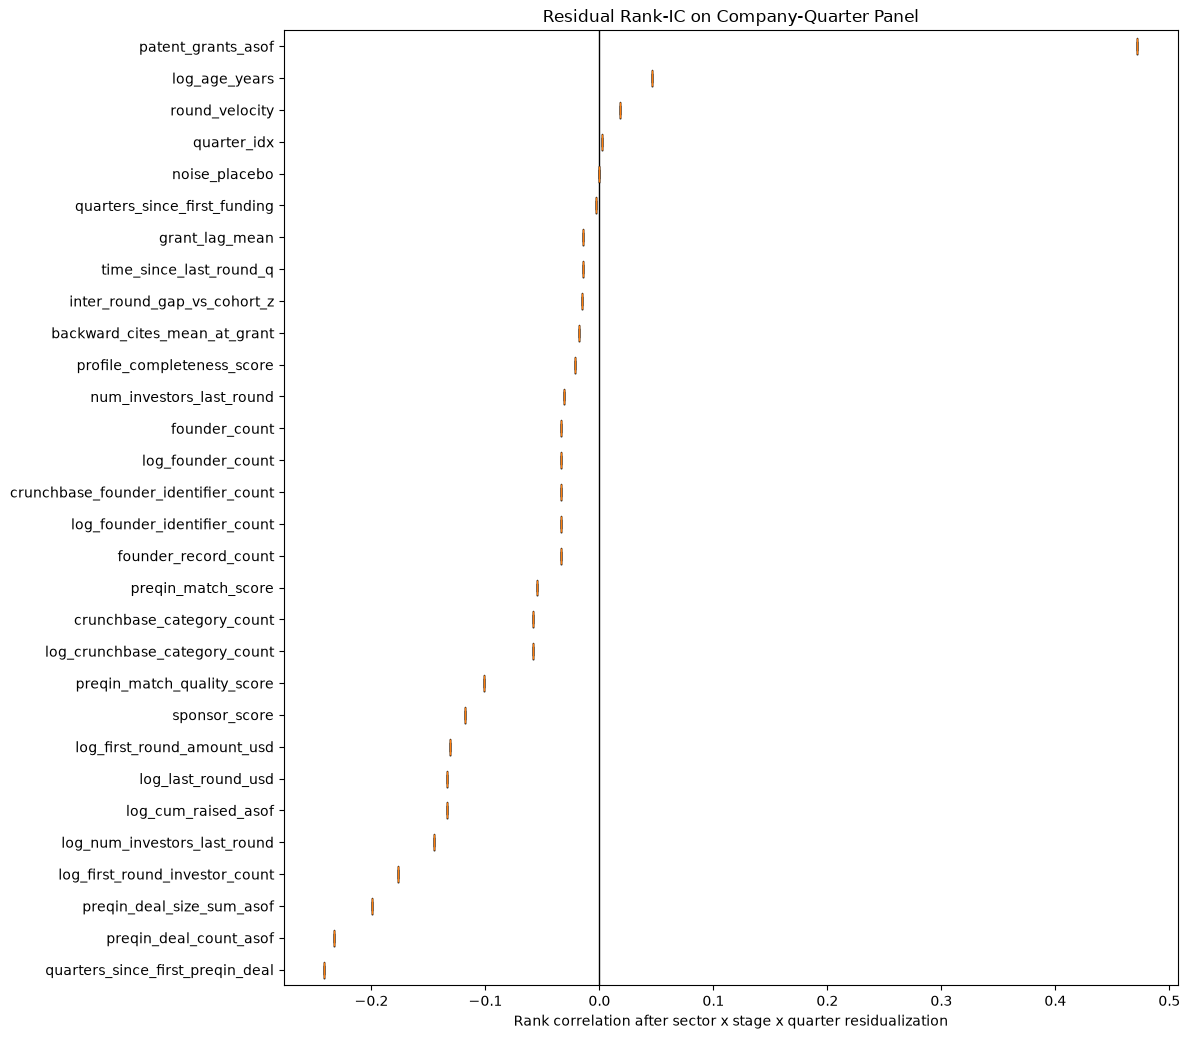

In [27]:
def residualize_by_group(values: pd.Series, groups: pd.Series) -> pd.Series:
    return values - values.groupby(groups).transform("mean")

def residual_rank_ic(frame: pd.DataFrame, feature: str) -> float:
    control_cols = [col for col in ["sector_bucket", "stage_bucket", "quarter_idx"] if col != feature]
    needed_cols = list(dict.fromkeys([feature, LABEL_COL, *control_cols]))
    data = frame[needed_cols].copy()
    data[feature] = pd.to_numeric(data[feature], errors="coerce")
    data[LABEL_COL] = pd.to_numeric(data[LABEL_COL], errors="coerce")
    data = data.dropna(subset=[feature, LABEL_COL])
    if len(data) < 100 or data[feature].nunique() < 3 or data[LABEL_COL].nunique() < 2:
        return np.nan
    group = data[control_cols].astype(str).agg("|".join, axis=1) if control_cols else pd.Series("all", index=data.index)
    x = residualize_by_group(data[feature].rank(pct=True), group)
    y = residualize_by_group(data[LABEL_COL].rank(pct=True), group)
    corr = spearmanr(x, y, nan_policy="omit").correlation
    return float(corr) if corr is not None and np.isfinite(corr) else np.nan

ic_rows = []
oot = model_frame[model_frame["split"].isin(["validation", "test"])].copy()
for family, cols in {**candidate_family_columns, "baseline": BASELINE_NUMERIC}.items():
    for col in cols:
        ic_rows.append({"family": family, "feature": col, "residual_rank_ic": residual_rank_ic(oot, col)})
ic = pd.DataFrame(ic_rows)
ic.to_csv(OUTPUT_DIR / "residual_rank_ic_reference_benchmark.csv", index=False)
display(ic.sort_values("residual_rank_ic", ascending=False))

plot_data = ic.dropna(subset=["residual_rank_ic"]).copy()
if not plot_data.empty:
    ordered = plot_data.groupby("feature")["residual_rank_ic"].median().sort_values().index.tolist()
    fig, ax = plt.subplots(figsize=(12, max(4, 0.35 * len(ordered))))
    ax.boxplot([plot_data.loc[plot_data["feature"].eq(f), "residual_rank_ic"].values for f in ordered], vert=False, tick_labels=ordered)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title("Residual Rank-IC on Company-Quarter Panel")
    ax.set_xlabel("Rank correlation after sector x stage x quarter residualization")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "residual_rank_ic_reference_benchmark.png", dpi=160)
    plt.show()

## Metric Functions

In [28]:
def precision_at_k(y_true, score, k=500) -> float:
    y = pd.Series(y_true).astype(int).reset_index(drop=True)
    s = pd.Series(score).astype(float).reset_index(drop=True)
    if len(y) == 0:
        return np.nan
    top = s.sort_values(ascending=False).head(min(k, len(y))).index
    return float(y.loc[top].mean())

def expected_calibration_error(y_true, score, n_bins=10) -> float:
    y = pd.Series(y_true).astype(float)
    s = pd.Series(score).astype(float).clip(0, 1)
    bins = pd.qcut(s.rank(method="first"), q=n_bins, duplicates="drop")
    data = pd.DataFrame({"y": y, "score": s, "bin": bins})
    grouped = data.groupby("bin", observed=False).agg(y_rate=("y", "mean"), p_mean=("score", "mean"), n=("y", "size"))
    return float((grouped["n"] / grouped["n"].sum() * (grouped["y_rate"] - grouped["p_mean"]).abs()).sum())

def safe_auc(y_true, score):
    y = pd.Series(y_true).astype(int)
    return float(roc_auc_score(y, score)) if y.nunique() == 2 else np.nan

def classification_metrics(y_true, score, threshold=None) -> dict:
    y = pd.Series(y_true).astype(int)
    threshold = float(np.nanquantile(score, 0.9)) if threshold is None and len(score) else 0.5
    pred = (pd.Series(score).astype(float) >= threshold).astype(int)
    return {
        "accuracy": float(accuracy_score(y, pred)),
        "precision": float(precision_score(y, pred, zero_division=0)),
        "recall": float(recall_score(y, pred, zero_division=0)),
        "f1": float(f1_score(y, pred, zero_division=0)),
    }

def metric_row(frame, score, model, variant, split_name="test"):
    y = frame[LABEL_COL].astype(int)
    row = {
        "model": model,
        "variant": variant,
        "split": split_name,
        "rows": len(frame),
        "events": int(y.sum()),
        "precision_at_500": precision_at_k(y, score, 500),
        "precision_at_5000": precision_at_k(y, score, 5000),
        "pr_auc": float(average_precision_score(y, score)) if y.nunique() == 2 else np.nan,
        "roc_auc": safe_auc(y, score),
        "brier": float(brier_score_loss(y, np.clip(score, 0, 1))),
        "ece": expected_calibration_error(y, score),
    }
    row.update(classification_metrics(y, score))
    return row

## Baseline Binary Hazard + Conditional Route Model

In [29]:
def make_preprocessor(numeric_cols, categorical_cols):
    return ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
    ])

train_panel = model_frame[model_frame["split"].eq("train")].copy()
validation_panel = model_frame[model_frame["split"].eq("validation")].copy()
test_panel = model_frame[model_frame["split"].eq("test")].copy()

baseline_features = BASELINE_NUMERIC + BASELINE_CATEGORICAL
baseline_clf = Pipeline([
    ("preprocess", make_preprocessor(BASELINE_NUMERIC, BASELINE_CATEGORICAL)),
    ("model", LogisticRegression(max_iter=500, class_weight="balanced")),
])
baseline_clf.fit(train_panel[baseline_features], train_panel[LABEL_COL].astype(int))
baseline_score = baseline_clf.predict_proba(test_panel[baseline_features])[:, 1]

route_train = train_panel[train_panel[LABEL_COL].astype(int).eq(1)].copy()
route_support = route_train.groupby(["split", "company_exit_route"], as_index=False).size()
route_priors = route_train["company_exit_route"].value_counts(normalize=True)
route_prior_table = route_priors.rename_axis("route").reset_index(name="conditional_probability")

baseline_predictions = test_panel[["company_uuid", "quarter_idx", LABEL_COL]].copy()
baseline_predictions["model"] = "binary_hazard_route"
baseline_predictions["variant"] = "baseline"
baseline_predictions["score"] = baseline_score
baseline_metrics = pd.DataFrame([metric_row(test_panel, baseline_score, "binary_hazard_route", "baseline")])

route_support.to_csv(OUTPUT_DIR / "baseline_stage2_route_support.csv", index=False)
route_prior_table.to_csv(OUTPUT_DIR / "baseline_conditional_route_probabilities.csv", index=False)

display(baseline_metrics)
display(route_support)
display(route_prior_table)

,model,variant,split,rows,events,precision_at_500,precision_at_5000,pr_auc,roc_auc,brier,ece,accuracy,precision,recall,f1
0,binary_hazard_route,baseline,test,1062229,83033,0.298,0.1958,0.330764,0.872542,0.170469,0.30877,0.897082,0.376256,0.481339,0.422359


,split,company_exit_route,size
0,train,ipo,95032
1,train,mna,422310
2,train,sponsor_sale,44242


,route,conditional_probability
0,mna,0.751998
1,ipo,0.169221
2,sponsor_sale,0.078781


## Logistic Regression, SVM RBF, and XGBoost on the Same Panel

In [30]:
def cap_training_rows(frame: pd.DataFrame, model_name: str, max_rows: int = 150_000) -> pd.DataFrame:
    if len(frame) <= max_rows or model_name == "logistic_regression":
        return frame.copy()
    events = frame[frame[LABEL_COL].astype(int).eq(1)]
    non_events = frame[frame[LABEL_COL].astype(int).eq(0)]
    if events.empty or non_events.empty:
        return frame.sample(n=min(max_rows, len(frame)), random_state=RANDOM_SEED).copy()
    event_n = min(len(events), max(1, int(max_rows * 0.50)))
    non_event_n = min(len(non_events), max_rows - event_n)
    if non_event_n <= 0:
        non_event_n = min(len(non_events), 1)
        event_n = min(len(events), max_rows - non_event_n)
    sampled_events = events.sample(n=event_n, random_state=RANDOM_SEED)
    sampled_non_events = non_events.sample(n=non_event_n, random_state=RANDOM_SEED)
    return pd.concat([sampled_events, sampled_non_events], ignore_index=True)

def model_specs():
    specs = {
        "logistic_regression": LogisticRegression(max_iter=500, class_weight="balanced", solver="lbfgs"),
    }
    # SVM with an RBF kernel is intentionally disabled by default because the
    # company-quarter panel is large. Re-enable on a capped diagnostic subset if needed.
    RUN_SVM_RBF = False
    if RUN_SVM_RBF:
        specs["svm_rbf"] = SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            cache_size=1000,
            random_state=RANDOM_SEED,
        )
    if HAS_XGBOOST:
        specs["xgboost"] = XGBClassifier(
            n_estimators=250, max_depth=3, learning_rate=0.05, subsample=0.8,
            colsample_bytree=0.8, objective="binary:logistic", eval_metric="logloss",
            random_state=RANDOM_SEED, n_jobs=4,
        )
    else:
        specs["xgboost_fallback_hist_gradient_boosting"] = HistGradientBoostingClassifier(
            max_iter=250, learning_rate=0.05, max_leaf_nodes=31, random_state=RANDOM_SEED
        )
    return specs

def fit_predict_sklearn(train, test, numeric_cols, categorical_cols, estimator):
    features = numeric_cols + categorical_cols
    y_train = train[LABEL_COL].astype(int)
    if y_train.nunique() < 2:
        return np.repeat(float(y_train.mean()), len(test))
    clf = Pipeline([("preprocess", make_preprocessor(numeric_cols, categorical_cols)), ("model", estimator)])
    clf.fit(train[features], y_train)
    if hasattr(clf.named_steps["model"], "predict_proba"):
        return clf.predict_proba(test[features])[:, 1]
    raw = clf.decision_function(test[features])
    return 1 / (1 + np.exp(-raw))

FEATURE_SETS = {
    "baseline": (BASELINE_NUMERIC, BASELINE_CATEGORICAL),
    "baseline_plus_noise_placebo": (BASELINE_NUMERIC + candidate_family_columns.get("placebo_noise", []), BASELINE_CATEGORICAL),
    "candidate_all_buildable": (ALL_CANDIDATE_FEATURES, []),
    "baseline_plus_all_candidate_features": (BASELINE_NUMERIC + ALL_CANDIDATE_FEATURES, BASELINE_CATEGORICAL),
}
for family, cols in candidate_family_columns.items():
    if family != "placebo_noise" and cols:
        FEATURE_SETS[f"baseline_plus_{family}"] = (BASELINE_NUMERIC + cols, BASELINE_CATEGORICAL)

all_predictions = [baseline_predictions]
all_metrics = [baseline_metrics]

for model_name, estimator in model_specs().items():
    for variant, (num_cols, cat_cols) in FEATURE_SETS.items():
        train = cap_training_rows(train_panel, model_name)
        print(f"{model_name} | {variant} | train={len(train):,}/{len(train_panel):,} | test={len(test_panel):,} | numeric={len(num_cols)} | categorical={len(cat_cols)}")
        score = fit_predict_sklearn(train, test_panel, num_cols, cat_cols, estimator)
        pred = test_panel[["company_uuid", "quarter_idx", LABEL_COL]].copy()
        pred["model"] = model_name
        pred["variant"] = variant
        pred["score"] = score
        all_predictions.append(pred)
        all_metrics.append(pd.DataFrame([metric_row(test_panel, score, model_name, variant)]))

predictions = pd.concat(all_predictions, ignore_index=True)
metrics = pd.concat(all_metrics, ignore_index=True)
predictions.to_csv(OUTPUT_DIR / "reference_benchmark_predictions.csv", index=False)
metrics.to_csv(OUTPUT_DIR / "reference_benchmark_metrics.csv", index=False)
display(metrics.sort_values(["model", "variant"]))

logistic_regression | baseline | train=5,338,013/5,338,013 | test=1,062,229 | numeric=6 | categorical=3
logistic_regression | baseline_plus_noise_placebo | train=5,338,013/5,338,013 | test=1,062,229 | numeric=7 | categorical=3
logistic_regression | candidate_all_buildable | train=5,338,013/5,338,013 | test=1,062,229 | numeric=37 | categorical=0
logistic_regression | baseline_plus_all_candidate_features | train=5,338,013/5,338,013 | test=1,062,229 | numeric=43 | categorical=3
logistic_regression | baseline_plus_syndicate_investor_supported | train=5,338,013/5,338,013 | test=1,062,229 | numeric=11 | categorical=3
logistic_regression | baseline_plus_founder_funding_dynamics_supported | train=5,338,013/5,338,013 | test=1,062,229 | numeric=20 | categorical=3
logistic_regression | baseline_plus_partner_profile_quality | train=5,338,013/5,338,013 | test=1,062,229 | numeric=10 | categorical=3
logistic_regression | baseline_plus_patent_quality | train=5,338,013/5,338,013 | test=1,062,229 | nume

,model,variant,split,rows,events,precision_at_500,precision_at_5000,pr_auc,roc_auc,brier,ece,accuracy,precision,recall,f1
0,binary_hazard_route,baseline,test,1062229,83033,0.298,0.1958,0.330764,0.872542,0.170469,0.308770,0.897082,0.376256,0.481339,0.422359
1,logistic_regression,baseline,test,1062229,83033,0.298,0.1958,0.330764,0.872542,0.170469,0.308770,0.897082,0.376256,0.481339,0.422359
4,logistic_regression,baseline_plus_all_candidate_features,test,1062229,83033,0.168,0.1710,0.321235,0.878824,0.167906,0.301067,0.898888,0.385284,0.492888,0.432494
6,logistic_regression,baseline_plus_founder_funding_dynamics_supported,test,1062229,83033,0.124,0.1986,0.351111,0.886978,0.160085,0.295679,0.906480,0.423258,0.541580,0.475164
2,logistic_regression,baseline_plus_noise_placebo,test,1062229,83033,0.298,0.1958,0.330642,0.872543,0.170470,0.308772,0.897082,0.376256,0.481339,0.422359
7,logistic_regression,baseline_plus_partner_profile_quality,test,1062229,83033,0.222,0.3288,0.310967,0.865131,0.174499,0.311753,0.892921,0.355480,0.454855,0.399074
8,logistic_regression,baseline_plus_patent_quality,test,1062229,83033,0.282,0.2018,0.330819,0.872610,0.170392,0.308714,0.897304,0.377887,0.485506,0.424989
9,logistic_regression,baseline_plus_preqin_institutional_confirmation,test,1062229,83033,0.100,0.1068,0.320451,0.872940,0.174818,0.312641,0.897503,0.378429,0.484398,0.424906
5,logistic_regression,baseline_plus_syndicate_investor_supported,test,1062229,83033,0.166,0.1944,0.358061,0.881998,0.164082,0.304446,0.909174,0.437023,0.561825,0.491627
3,logistic_regression,candidate_all_buildable,test,1062229,83033,0.170,0.1654,0.293598,0.870129,0.111139,0.209987,0.891963,0.350659,0.448593,0.393626


## Precision@500 Bootstrap CI and Family Promotion Gates

In [31]:
def bootstrap_precision_delta(predictions, model, variant, baseline_variant="baseline", n_boot=500, seed=42):
    rng = np.random.default_rng(seed)
    base = predictions[(predictions["model"].eq(model)) & (predictions["variant"].eq(baseline_variant))].copy()
    cand = predictions[(predictions["model"].eq(model)) & (predictions["variant"].eq(variant))].copy()
    merged = base[["company_uuid", "quarter_idx", LABEL_COL, "score"]].rename(columns={"score": "base_score"}).merge(
        cand[["company_uuid", "quarter_idx", "score"]].rename(columns={"score": "cand_score"}),
        on=["company_uuid", "quarter_idx"],
        how="inner",
    )
    if merged.empty:
        return np.nan, np.nan, np.nan
    ids = merged.index.to_numpy()
    deltas = []
    for _ in range(n_boot):
        sample_idx = rng.choice(ids, size=len(ids), replace=True)
        sample = merged.loc[sample_idx]
        deltas.append(precision_at_k(sample[LABEL_COL], sample["cand_score"]) - precision_at_k(sample[LABEL_COL], sample["base_score"]))
    lo, hi = np.nanpercentile(deltas, [2.5, 97.5])
    return float(np.nanmean(deltas)), float(lo), float(hi)

gate_rows = []
for model in sorted(predictions["model"].unique()):
    model_metrics = metrics[metrics["model"].eq(model)].copy()
    base = model_metrics[model_metrics["variant"].eq("baseline")]
    if base.empty:
        continue
    base = base.iloc[0]
    for _, row in model_metrics.iterrows():
        variant = row["variant"]
        if variant == "baseline":
            delta, lo, hi = 0.0, np.nan, np.nan
        else:
            delta, lo, hi = bootstrap_precision_delta(predictions, model, variant)
        brier_delta = float(row["brier"] - base["brier"])
        ece_delta = float(row["ece"] - base["ece"])
        gate_rows.append({
            "model": model,
            "variant": variant,
            "precision_at_500": row["precision_at_500"],
            "delta_vs_baseline": delta,
            "ci_low": lo,
            "ci_high": hi,
            "brier_delta": brier_delta,
            "ece_delta": ece_delta,
            "promotion_pass": int((variant != "baseline") and np.isfinite(lo) and lo > 0 and brier_delta <= 0.0025 and ece_delta <= 0.01),
        })

promotion = pd.DataFrame(gate_rows)
promotion.to_csv(OUTPUT_DIR / "family_promotion_gates_reference_benchmark.csv", index=False)
display(promotion.sort_values(["model", "variant"]))

placebo_pass = promotion[promotion["variant"].eq("baseline_plus_noise_placebo") & promotion["promotion_pass"].eq(1)]
if not placebo_pass.empty:
    raise RuntimeError("Noise placebo passed a promotion gate. Thresholds are wrong; do not trust feature promotion results.")
print("Noise placebo did not pass promotion gates.")

,model,variant,precision_at_500,delta_vs_baseline,ci_low,ci_high,brier_delta,ece_delta,promotion_pass
0,binary_hazard_route,baseline,0.298,0.000000,NaN,NaN,0.000000e+00,0.000000,0
1,logistic_regression,baseline,0.298,0.000000,NaN,NaN,0.000000e+00,0.000000,0
4,logistic_regression,baseline_plus_all_candidate_features,0.168,-0.131604,-0.18200,-0.08295,-2.562766e-03,-0.007703,0
6,logistic_regression,baseline_plus_founder_funding_dynamics_supported,0.124,-0.177656,-0.22600,-0.12800,-1.038370e-02,-0.013091,0
2,logistic_regression,baseline_plus_noise_placebo,0.298,-0.000676,-0.00600,0.00200,7.952913e-07,0.000002,0
7,logistic_regression,baseline_plus_partner_profile_quality,0.222,-0.075820,-0.12400,-0.03095,4.030101e-03,0.002983,0
8,logistic_regression,baseline_plus_patent_quality,0.282,-0.017008,-0.03400,-0.00200,-7.726364e-05,-0.000057,0
9,logistic_regression,baseline_plus_preqin_institutional_confirmation,0.100,-0.199612,-0.25400,-0.15095,4.349220e-03,0.003871,0
5,logistic_regression,baseline_plus_syndicate_investor_supported,0.166,-0.132560,-0.17400,-0.09400,-6.386531e-03,-0.004325,0
3,logistic_regression,candidate_all_buildable,0.170,-0.129276,-0.18200,-0.08200,-5.932972e-02,-0.098783,0


Noise placebo did not pass promotion gates.


## Calibration Diagnostics

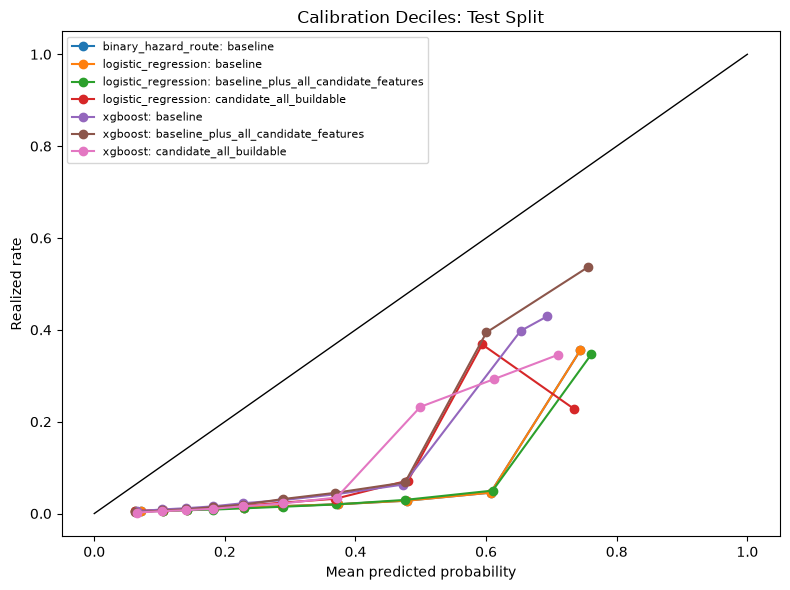

In [32]:
def calibration_deciles(frame):
    data = frame.copy()
    data["score"] = data["score"].clip(0, 1)
    data["decile"] = pd.qcut(data["score"].rank(method="first"), q=10, labels=False, duplicates="drop")
    return data.groupby(["model", "variant", "decile"], as_index=False).agg(
        predicted=("score", "mean"),
        realized=(LABEL_COL, "mean"),
        rows=(LABEL_COL, "size"),
    )

cal = calibration_deciles(predictions)
cal.to_csv(OUTPUT_DIR / "calibration_deciles_reference_benchmark.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 6))
for (model, variant), grp in cal.groupby(["model", "variant"]):
    if variant in ["baseline", "baseline_plus_all_candidate_features", "candidate_all_buildable"]:
        ax.plot(grp["predicted"], grp["realized"], marker="o", label=f"{model}: {variant}")
ax.plot([0, 1], [0, 1], color="black", linewidth=1)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Realized rate")
ax.set_title("Calibration Deciles: Test Split")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "calibration_deciles_reference_benchmark.png", dpi=160)
plt.show()

## Route Support and Policy-Style Ranking Diagnostics

In [33]:
route_support_all = (
    model_frame[model_frame[LABEL_COL].astype(int).eq(1)]
    .groupby(["split", "company_exit_route"], as_index=False)
    .agg(rows=(LABEL_COL, "size"), companies=("company_uuid", "nunique"))
)
route_support_all.to_csv(OUTPUT_DIR / "route_support_reference_benchmark.csv", index=False)
display(route_support_all)

policy_rows = []
for top_k in [500, 5000]:
    for (model, variant), grp in predictions.groupby(["model", "variant"]):
        top = grp.sort_values("score", ascending=False).head(min(top_k, len(grp))).copy()
        policy_rows.append({
            "model": model,
            "variant": variant,
            "top_k": top_k,
            "selected_rows": len(top),
            "selected_companies": top["company_uuid"].nunique(),
            "selected_realized_rate": float(top[LABEL_COL].mean()) if len(top) else np.nan,
            "test_base_rate": float(grp[LABEL_COL].mean()) if len(grp) else np.nan,
            "lift": float(top[LABEL_COL].mean() / grp[LABEL_COL].mean()) if len(top) and grp[LABEL_COL].mean() > 0 else np.nan,
        })
policy_rank_backtest = pd.DataFrame(policy_rows)
policy_rank_backtest.to_csv(OUTPUT_DIR / "rank_policy_backtest_topk.csv", index=False)
display(policy_rank_backtest.sort_values(["model", "variant"]))

,split,company_exit_route,rows,companies
0,test,ipo,4934,1713
1,test,mna,73501,26643
2,test,sponsor_sale,4598,1622
3,train,ipo,95032,14629
4,train,mna,422310,63131
5,train,sponsor_sale,44242,6991
6,validation,ipo,21216,4268
7,validation,mna,228716,42164
8,validation,sponsor_sale,18692,3611


,model,variant,top_k,selected_rows,selected_companies,selected_realized_rate,test_base_rate,lift
0,binary_hazard_route,baseline,500,500,215,0.2980,0.078169,3.812270
19,binary_hazard_route,baseline,5000,5000,1807,0.1958,0.078169,2.504841
1,logistic_regression,baseline,500,500,215,0.2980,0.078169,3.812270
20,logistic_regression,baseline,5000,5000,1807,0.1958,0.078169,2.504841
2,logistic_regression,baseline_plus_all_candidate_features,500,500,176,0.1680,0.078169,2.149199
21,logistic_regression,baseline_plus_all_candidate_features,5000,5000,1608,0.1710,0.078169,2.187578
3,logistic_regression,baseline_plus_founder_funding_dynamics_supported,500,500,188,0.1240,0.078169,1.586314
22,logistic_regression,baseline_plus_founder_funding_dynamics_supported,5000,5000,1722,0.1986,0.078169,2.540661
4,logistic_regression,baseline_plus_noise_placebo,500,500,215,0.2980,0.078169,3.812270
23,logistic_regression,baseline_plus_noise_placebo,5000,5000,1807,0.1958,0.078169,2.504841


## Final Summary Tables

In [34]:
summary = metrics.merge(
    promotion[["model", "variant", "delta_vs_baseline", "ci_low", "ci_high", "brier_delta", "ece_delta", "promotion_pass"]],
    on=["model", "variant"],
    how="left",
)
summary["Precision@500"] = (summary["precision_at_500"] * 100).map(lambda x: f"{x:.2f}%")
summary["Precision@5000"] = (summary["precision_at_5000"] * 100).map(lambda x: f"{x:.2f}%")
summary["Delta vs baseline"] = (summary["delta_vs_baseline"] * 100).map(lambda x: "" if pd.isna(x) else f"{x:+.2f}%")
summary["95% bootstrap CI"] = summary.apply(
    lambda r: "--" if pd.isna(r["ci_low"]) else f"[{100*r['ci_low']:+.2f}%, {100*r['ci_high']:+.2f}%]",
    axis=1,
)
display_cols = [
    "model", "variant", "Precision@500", "Precision@5000", "Delta vs baseline", "95% bootstrap CI",
    "pr_auc", "roc_auc", "brier", "brier_delta", "ece", "ece_delta",
    "accuracy", "precision", "recall", "f1", "promotion_pass",
]
summary[display_cols].to_csv(OUTPUT_DIR / "final_reference_benchmark_summary.csv", index=False)
display(summary[display_cols].sort_values(["model", "variant"]))

print("Outputs written to:", OUTPUT_DIR)

,model,variant,Precision@500,Precision@5000,Delta vs baseline,95% bootstrap CI,pr_auc,roc_auc,brier,brier_delta,ece,ece_delta,accuracy,precision,recall,f1,promotion_pass
0,binary_hazard_route,baseline,29.80%,19.58%,+0.00%,--,0.330764,0.872542,0.170469,0.000000e+00,0.308770,0.000000,0.897082,0.376256,0.481339,0.422359,0
1,logistic_regression,baseline,29.80%,19.58%,+0.00%,--,0.330764,0.872542,0.170469,0.000000e+00,0.308770,0.000000,0.897082,0.376256,0.481339,0.422359,0
4,logistic_regression,baseline_plus_all_candidate_features,16.80%,17.10%,-13.16%,"[-18.20%, -8.30%]",0.321235,0.878824,0.167906,-2.562766e-03,0.301067,-0.007703,0.898888,0.385284,0.492888,0.432494,0
6,logistic_regression,baseline_plus_founder_funding_dynamics_supported,12.40%,19.86%,-17.77%,"[-22.60%, -12.80%]",0.351111,0.886978,0.160085,-1.038370e-02,0.295679,-0.013091,0.906480,0.423258,0.541580,0.475164,0
2,logistic_regression,baseline_plus_noise_placebo,29.80%,19.58%,-0.07%,"[-0.60%, +0.20%]",0.330642,0.872543,0.170470,7.952913e-07,0.308772,0.000002,0.897082,0.376256,0.481339,0.422359,0
7,logistic_regression,baseline_plus_partner_profile_quality,22.20%,32.88%,-7.58%,"[-12.40%, -3.10%]",0.310967,0.865131,0.174499,4.030101e-03,0.311753,0.002983,0.892921,0.355480,0.454855,0.399074,0
8,logistic_regression,baseline_plus_patent_quality,28.20%,20.18%,-1.70%,"[-3.40%, -0.20%]",0.330819,0.872610,0.170392,-7.726364e-05,0.308714,-0.000057,0.897304,0.377887,0.485506,0.424989,0
9,logistic_regression,baseline_plus_preqin_institutional_confirmation,10.00%,10.68%,-19.96%,"[-25.40%, -15.10%]",0.320451,0.872940,0.174818,4.349220e-03,0.312641,0.003871,0.897503,0.378429,0.484398,0.424906,0
5,logistic_regression,baseline_plus_syndicate_investor_supported,16.60%,19.44%,-13.26%,"[-17.40%, -9.40%]",0.358061,0.881998,0.164082,-6.386531e-03,0.304446,-0.004325,0.909174,0.437023,0.561825,0.491627,0
3,logistic_regression,candidate_all_buildable,17.00%,16.54%,-12.93%,"[-18.20%, -8.20%]",0.293598,0.870129,0.111139,-5.932972e-02,0.209987,-0.098783,0.891963,0.350659,0.448593,0.393626,0


Outputs written to: D:\Columbia\SummerProject\L3_9_2_VC_and_PE_Exit_Prediction_distribution\project\outputs\reference_benchmark


## Leakage and Sanity Diagnostics for High Top-K Results

Very high top-500 realized rates are treated as a diagnostic trigger, not as proof of model quality. This section checks the main failure modes that can make policy-style precision look too good:

- whether the same company appears in both train and test company-quarter rows;
- whether top-ranked test observations are concentrated immediately before the exit event;
- whether top-500 rows are repeated observations of the same companies;
- whether Preqin or buyout-linked features are acting as near-event proxies;
- whether unusually high top-500 precision is present even in the baseline feature set.

The output tables are audit artifacts. A high value here does not automatically prove leakage, but it identifies the variants and rows that should be inspected before interpreting the ranking results.

In [35]:
audit_base_cols = [
    "company_uuid", "quarter_idx", LABEL_COL, "exit_q", "company_exit_route",
    "preqin_institutional_confirmation", "preqin_deal_count_asof",
    "quarters_since_first_preqin_deal", "preqin_deal_size_sum_asof",
    "crosswalk_matched_asof", "log_enterprise_value_at_entry",
    "enterprise_value_missing_flag",
]
audit_base_cols = [col for col in audit_base_cols if col in test_panel.columns]
test_audit_base = test_panel[audit_base_cols].copy()

train_companies = set(train_panel["company_uuid"].dropna().unique())
test_companies = set(test_panel["company_uuid"].dropna().unique())
company_overlap = train_companies.intersection(test_companies)

train_test_overlap_audit = pd.DataFrame([{
    "train_companies": len(train_companies),
    "test_companies": len(test_companies),
    "overlap_companies": len(company_overlap),
    "share_of_test_companies_seen_in_train": len(company_overlap) / len(test_companies) if test_companies else np.nan,
}])
train_test_overlap_audit.to_csv(OUTPUT_DIR / "leakage_audit_train_test_company_overlap.csv", index=False)
display(train_test_overlap_audit)

topk_audit_rows = []
topk_detail_frames = []
for top_k in [500, 5000]:
    for (model, variant), pred_grp in predictions.groupby(["model", "variant"]):
        top = pred_grp.sort_values("score", ascending=False).head(min(top_k, len(pred_grp))).copy()
        top = top.merge(test_audit_base, on=["company_uuid", "quarter_idx", LABEL_COL], how="left")
        top["company_seen_in_train"] = top["company_uuid"].isin(company_overlap).astype(int)
        if "exit_q" in top.columns:
            top["quarters_to_exit"] = top["exit_q"] - top["quarter_idx"]
            event_top = top[top[LABEL_COL].astype(int).eq(1)].copy()
        else:
            top["quarters_to_exit"] = np.nan
            event_top = top.iloc[0:0].copy()

        row = {
            "model": model,
            "variant": variant,
            "top_k": top_k,
            "top_rows": len(top),
            "top_companies": top["company_uuid"].nunique(),
            "duplicate_company_rows": len(top) - top["company_uuid"].nunique(),
            "top_realized_rate": float(top[LABEL_COL].mean()) if len(top) else np.nan,
            "company_seen_in_train_share": float(top["company_seen_in_train"].mean()) if len(top) else np.nan,
            "event_rows": len(event_top),
            "event_rows_with_exit_q": int(event_top["quarters_to_exit"].notna().sum()) if "quarters_to_exit" in event_top.columns else 0,
            "median_quarters_to_exit_among_events": float(event_top["quarters_to_exit"].median()) if len(event_top) and event_top["quarters_to_exit"].notna().any() else np.nan,
            "share_event_rows_exit_within_1q": float(event_top["quarters_to_exit"].between(0, 1).mean()) if len(event_top) else np.nan,
            "share_event_rows_exit_within_2q": float(event_top["quarters_to_exit"].between(0, 2).mean()) if len(event_top) else np.nan,
            "high_precision_flag_ge_75pct": int(float(top[LABEL_COL].mean()) >= 0.75) if len(top) else 0,
        }
        for col in [
            "preqin_institutional_confirmation", "crosswalk_matched_asof",
            "enterprise_value_missing_flag",
        ]:
            if col in top.columns:
                row[f"top_mean_{col}"] = float(pd.to_numeric(top[col], errors="coerce").mean())
        for col in [
            "preqin_deal_count_asof", "quarters_since_first_preqin_deal",
            "preqin_deal_size_sum_asof", "log_enterprise_value_at_entry",
        ]:
            if col in top.columns:
                row[f"top_median_{col}"] = float(pd.to_numeric(top[col], errors="coerce").median())

        top["top_k"] = top_k
        top["top_rank"] = np.arange(1, len(top) + 1)
        top["model"] = model
        top["variant"] = variant
        keep_detail_cols = [
            "model", "variant", "top_k", "top_rank", "company_uuid", "quarter_idx", "score", LABEL_COL,
            "company_exit_route", "exit_q", "quarters_to_exit", "company_seen_in_train",
            "preqin_institutional_confirmation", "crosswalk_matched_asof",
            "preqin_deal_count_asof", "quarters_since_first_preqin_deal",
            "preqin_deal_size_sum_asof", "log_enterprise_value_at_entry",
            "enterprise_value_missing_flag",
        ]
        keep_detail_cols = [col for col in keep_detail_cols if col in top.columns]
        topk_detail_frames.append(top[keep_detail_cols])
        topk_audit_rows.append(row)

topk_leakage_audit = pd.DataFrame(topk_audit_rows)
topk_leakage_audit.to_csv(OUTPUT_DIR / "leakage_audit_topk_summary.csv", index=False)
display(topk_leakage_audit.sort_values(["high_precision_flag_ge_75pct", "top_realized_rate"], ascending=[False, False]))

topk_leakage_detail = pd.concat(topk_detail_frames, ignore_index=True) if topk_detail_frames else pd.DataFrame()
topk_leakage_detail.to_csv(OUTPUT_DIR / "leakage_audit_topk_detail.csv", index=False)
display(topk_leakage_detail.head(25))

,train_companies,test_companies,overlap_companies,share_of_test_companies_seen_in_train
0,274139,281488,173772,0.617334


,model,variant,top_k,top_rows,top_companies,duplicate_company_rows,top_realized_rate,company_seen_in_train_share,event_rows,event_rows_with_exit_q,...,share_event_rows_exit_within_1q,share_event_rows_exit_within_2q,high_precision_flag_ge_75pct,top_mean_preqin_institutional_confirmation,top_mean_crosswalk_matched_asof,top_mean_enterprise_value_missing_flag,top_median_preqin_deal_count_asof,top_median_quarters_since_first_preqin_deal,top_median_preqin_deal_size_sum_asof,top_median_log_enterprise_value_at_entry
12,xgboost,baseline_plus_founder_funding_dynamics_supported,500,500,168,332,0.6000,0.9820,300,300,...,0.160000,0.336667,0,0.6020,0.6020,1.0,1.0,15.0,0.000,NaN
17,xgboost,baseline_plus_syndicate_investor_supported,500,500,148,352,0.5920,0.9920,296,296,...,0.165541,0.341216,0,1.0000,1.0000,1.0,2.0,26.0,3.380,NaN
31,xgboost,baseline_plus_founder_funding_dynamics_supported,5000,5000,1534,3466,0.5482,0.9594,2741,2741,...,0.149216,0.290040,0,0.2400,0.2400,1.0,0.0,0.0,0.000,NaN
14,xgboost,baseline_plus_partner_profile_quality,500,500,145,355,0.5280,1.0000,264,264,...,0.166667,0.329545,0,0.1340,0.1340,1.0,0.0,0.0,0.000,NaN
36,xgboost,baseline_plus_syndicate_investor_supported,5000,5000,1482,3518,0.5094,0.9682,2547,2547,...,0.153514,0.302709,0,0.3020,0.3020,1.0,0.0,0.0,0.000,NaN
18,xgboost,candidate_all_buildable,500,500,174,326,0.5080,0.7780,254,254,...,0.188976,0.338583,0,0.0240,0.0240,1.0,0.0,0.0,0.000,NaN
30,xgboost,baseline_plus_all_candidate_features,5000,5000,1594,3406,0.5024,0.9704,2512,2512,...,0.192277,0.342357,0,0.0244,0.0244,1.0,0.0,0.0,0.000,NaN
11,xgboost,baseline_plus_all_candidate_features,500,500,170,330,0.4920,0.9960,246,246,...,0.178862,0.337398,0,0.0340,0.0340,1.0,0.0,0.0,0.000,NaN
33,xgboost,baseline_plus_partner_profile_quality,5000,5000,1508,3492,0.4650,0.9990,2325,2325,...,0.187527,0.332473,0,0.0382,0.0382,1.0,0.0,0.0,0.000,NaN
29,xgboost,baseline,5000,5000,1583,3417,0.3980,0.9458,1990,1990,...,0.150754,0.292462,0,0.5214,0.5214,1.0,1.0,3.0,0.000,NaN


,model,variant,top_k,top_rank,company_uuid,quarter_idx,score,realized_hard_timely_liquidity_by_horizon,company_exit_route,exit_q,quarters_to_exit,company_seen_in_train,preqin_institutional_confirmation,crosswalk_matched_asof,preqin_deal_count_asof,quarters_since_first_preqin_deal,preqin_deal_size_sum_asof,log_enterprise_value_at_entry,enterprise_value_missing_flag
0,binary_hazard_route,baseline,500,1,134a6fb5-4804-4978-9394-7f3da6e57d5b,8091,0.892133,0,no_exit,<NA>,<NA>,1,1,1,2.0,70.0,32.75,NaN,1
1,binary_hazard_route,baseline,500,2,25751889-2de9-4bf7-a874-a299de436a79,8091,0.890062,0,no_exit,<NA>,<NA>,1,1,1,1.0,13.0,0.00,NaN,1
2,binary_hazard_route,baseline,500,3,134a6fb5-4804-4978-9394-7f3da6e57d5b,8090,0.890038,0,no_exit,<NA>,<NA>,1,1,1,2.0,69.0,32.75,NaN,1
3,binary_hazard_route,baseline,500,4,2995847a-e4cb-4d28-9ed5-2b2737a5fb18,8091,0.889832,0,no_exit,<NA>,<NA>,1,1,1,1.0,52.0,0.00,NaN,1
4,binary_hazard_route,baseline,500,5,ff937b1d-5238-99ea-f887-ee11d58dc265,8091,0.888645,1,mna,8094,3,1,1,1,1.0,1.0,0.00,NaN,1
5,binary_hazard_route,baseline,500,6,25751889-2de9-4bf7-a874-a299de436a79,8090,0.887916,0,no_exit,<NA>,<NA>,1,1,1,1.0,12.0,0.00,NaN,1
6,binary_hazard_route,baseline,500,7,134a6fb5-4804-4978-9394-7f3da6e57d5b,8089,0.887908,0,no_exit,<NA>,<NA>,1,1,1,2.0,68.0,32.75,NaN,1
7,binary_hazard_route,baseline,500,8,2995847a-e4cb-4d28-9ed5-2b2737a5fb18,8090,0.887693,0,no_exit,<NA>,<NA>,1,1,1,1.0,51.0,0.00,NaN,1
8,binary_hazard_route,baseline,500,9,43dea2c1-4dde-4b85-911e-d7c02e7b2c50,8088,0.887240,1,mna,8089,1,1,1,1,1.0,30.0,248.50,NaN,1
9,binary_hazard_route,baseline,500,10,2e7b5e75-5a7d-45dc-a0b9-708a4ffa1463,8091,0.886377,1,mna,8096,5,1,1,1,1.0,5.0,80.00,NaN,1
